# Ch3: Data Modeling Using the Entity-Relationship (ER) Model

Textbook: Elmasri and Navathe, *Fundamentals of Database Systems*, 7th Edition,
Chapter 3. Read Sections 3.1-3.7, 3.9.1-3.9.2, and 3.10.


## Teaching Summary

An ER diagram describes the objects a database represents, their properties,
and the rules connecting them. Start with a small campus example, draw one
concept at a time, and then assemble the design. The tables below are descriptions
of fictional objects and facts, not proposed relational tables or SQL output.

Ch1 introduced databases and their users. Ch2 distinguished a schema from its
current state. Here you will design a conceptual schema from stated requirements.
You need no SQL, Python, drawing application, or database installation.
Paper is enough for the drawing exercises.

The worked examples explain the figures and tables step by step. They show
the data, what to look for, and the conclusion, without requiring you to complete
a practice task first. Practice provides additional variations; submit only
the work the instructor assigns.

By the end, you should be able to identify entities and attributes, justify keys,
read and draw relationship constraints, identify weak entities, and explain why
a three-part fact may need a ternary relationship. You should also be able to
check whether a diagram permits a state that the requirements forbid.

All campus records are synthetic. The main example covers **Fall 2026 only**.
A section is a particular class offering of a course during that term.
Separate small variants introduce rooms, cards, and mentoring; they are not
additional requirements for the final campus diagram.


## 1. From Requirements to a Diagram

An **entity-relationship (ER) model** is a high-level conceptual data model.
It describes meaning without choosing relational tables or disk structures.
A **miniworld** is the portion of the world that the database represents.

Consider two requirements: each section belongs to exactly one course, and
different courses may reuse a section number. The first requirement introduces
COURSE, SECTION, and a connection. The second asks how a section is identified.
It does not tell us how to implement that identification in SQL.

The core campus requirements are:

| Fact or rule | Meaning in this example |
|---|---|
| Students have unique StudentId values and zero or more recorded phone numbers. | Different students cannot share a StudentId. |
| Courses have unique CourseCode values. | A course can exist before any section is offered. |
| Each section belongs to exactly one course. | SectionNo is unique within its course, not across all courses. |
| Each section has exactly one instructor. | An instructor may teach zero or more sections. |
| Students may enroll in several sections. | A section may have zero or more students. |
| A grade, when available, belongs to one enrollment. | A student's different enrollments may have different grades. |
| An instructor may approve a student for a particular course. | Each approval names all three participants. |

InstructorId uniquely identifies an instructor. Approvals are recorded separately
from enrollment: these requirements do not make an approval a prerequisite for
enrollment. Repeated approval events with the same three participants are outside
this example.

**Prediction:** Which of the first two course-section requirements would be lost
if a drawing showed only two named boxes without a relationship or constraints?


### Start with facts and rules

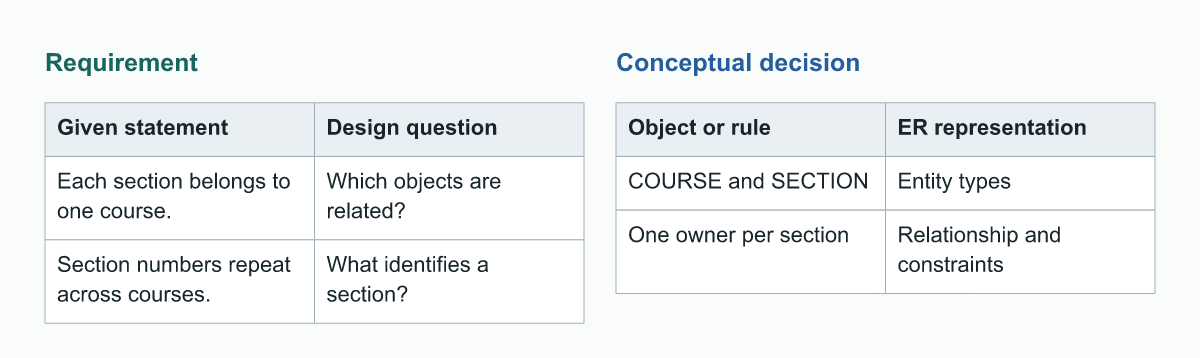

An ER diagram describes the miniworld before relational mapping or storage choices.


### Read the Diagram

The boxes alone name the types but do not express which course owns a section.
Adding a relationship states the connection. Adding constraints states how many
owners each section may have. Identification still needs a key analysis.

A requirement such as "show all sections taught by I1" is a useful design check:
the schema must preserve enough information to answer it. Choosing an index is
a later physical-design question, not an ER symbol.

**Practice:** For "each library copy belongs to one book edition," name the two
types and write one question about copy identification. Check that your question
distinguishes a copy number unique everywhere from one unique only within an edition.


## 2. Entity, Entity Type, and Entity Set

An **entity** is one distinguishable object, such as the student identified by
S101. An **entity type** describes entities with the same kinds of properties.
An **entity set** contains the entities of that type at a particular time.

STUDENT is the type. S101, S102, and S103 are three entities in its current set.
StudentId is an attribute; S101 is an attribute value used here to identify one
entity. The person is not the same thing as the identifier string.

The example displays all three listed properties: StudentId, Name, and Phone.
S101 has two recorded phone values, S102 has one, and S103 has none recorded.
The invented phone strings are the same ones used in Section 3. Semicolons
separate values for reading, not as a proposed SQL storage format.

**Prediction:** Adding S104 without changing any attribute definitions changes
the entity type, the current entity set, or both?


### One entity is not the whole entity type

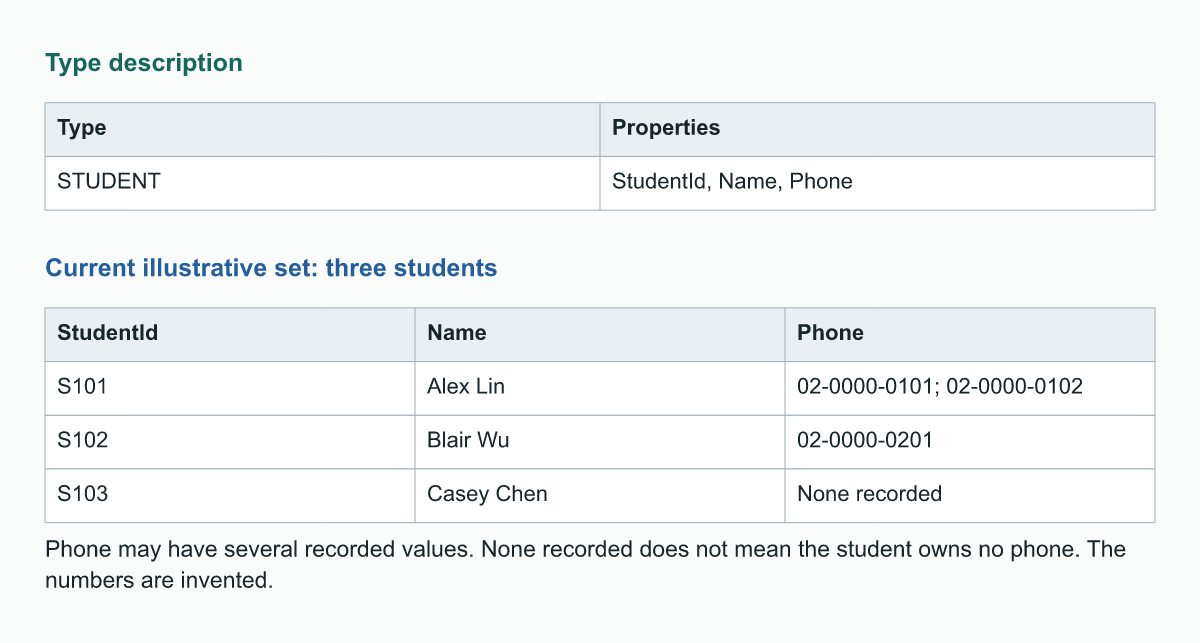

STUDENT is the type; S101 identifies one entity. Adding a fourth student changes the set, not the type definition.


### Read the Diagram

The figure shows the original three students. Adding S104 would make four;
the type would still describe students using the same properties.
This is the Ch2 distinction between the
schema and a state, now applied to entities.

A rectangle in an ER schema names an entity type, not one particular student.
Do not draw a new schema rectangle for every row in an example.

**Practice:** Describe COURSE at all three levels: one course, the type, and a
current set of two courses. Check that the set contains objects, whereas the
type description states their shared properties.


## 3. Attributes Describe an Entity

An **attribute** describes a property of an entity. For this expanded student
profile, suppose the application needs to search given and family names
separately, keep several phone numbers, and count current enrollments.
Draw an attribute as an oval connected to its entity type. This connection
attaches the property; it is not a separate relationship type.

| Student | GivenName | FamilyName | Recorded Phone values | EnrollmentCount |
|---|---|---|---|---:|
| S101 | Alex | Lin | 02-0000-0101; 02-0000-0102 | 2 |
| S102 | Blair | Wu | 02-0000-0201 | 1 |
| S103 | Casey | Chen | None recorded | 0 |

The phone strings are invented. Semicolons separate values for reading;
they are not a recommendation to store a list in one SQL column.

A **simple attribute** has no components used by this model. A **composite
attribute** groups meaningful components: Name contains GivenName and FamilyName.
Name need not be composite in every application; that choice depends on the
information the application needs.

A **single-valued attribute** has one value for an entity when known.
A **multivalued attribute** may have several values for one entity.
Phone is multivalued here. Composite and multivalued describe different properties.
For example, an optional Contact attribute could contain several
(Label, PhoneNumber) pairs. Each pair has components, and a student can have
several pairs. This is a small example of a **complex attribute**.

A **stored attribute** supplies a recorded value. A **derived attribute** is
calculated from other information. EnrollmentCount is derived by counting the
student's enrollment relationships; it is not the sum of grade values.

**Prediction:** Which attribute needs a double oval, and which needs a dashed
oval? How many phone values does S101 have?


### Different attribute properties use different symbols

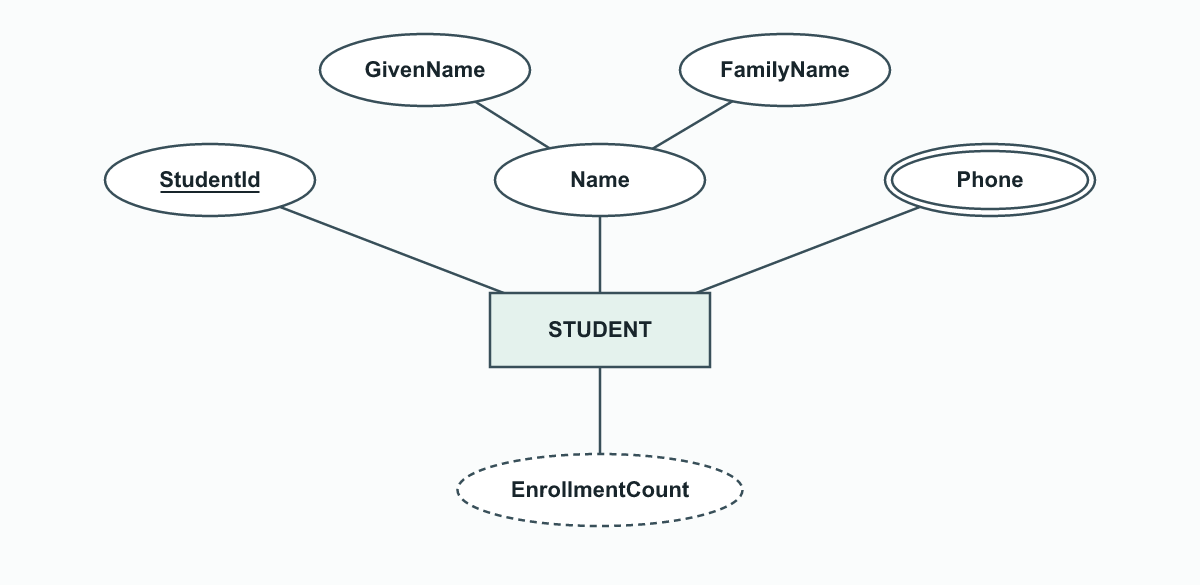

Name has components; Phone can have several values; EnrollmentCount is calculated from enrollments.


### Read the Diagram

Phone has a double oval because S101 may have more than one phone value.
EnrollmentCount has a dashed oval because it is calculated. Name connects to
two component ovals. StudentId is underlined because it is a key, discussed next.

Count S101's two enrollment facts in Section 6: the derived value is 2.
If one enrollment is removed, this count becomes 1. Its value depends on the
current relationship set, not on the number of phones.


### Worked Example: Two Contacts for One Student

Keep the same invented numbers for S101, but now label each contact:

| Student | Label | PhoneNumber |
|---|---|---|
| S101 | home | 02-0000-0101 |
| S101 | mobile | 02-0000-0102 |

Both rows describe the same student. Each row supplies one Contact value with
two components. This contact-list variant replaces the bare Phone list; it does
not require two redundant lists in the core design.

**Prediction:** How many student entities, Contact values, and components per
Contact value are shown?


### Several values can each have meaningful components

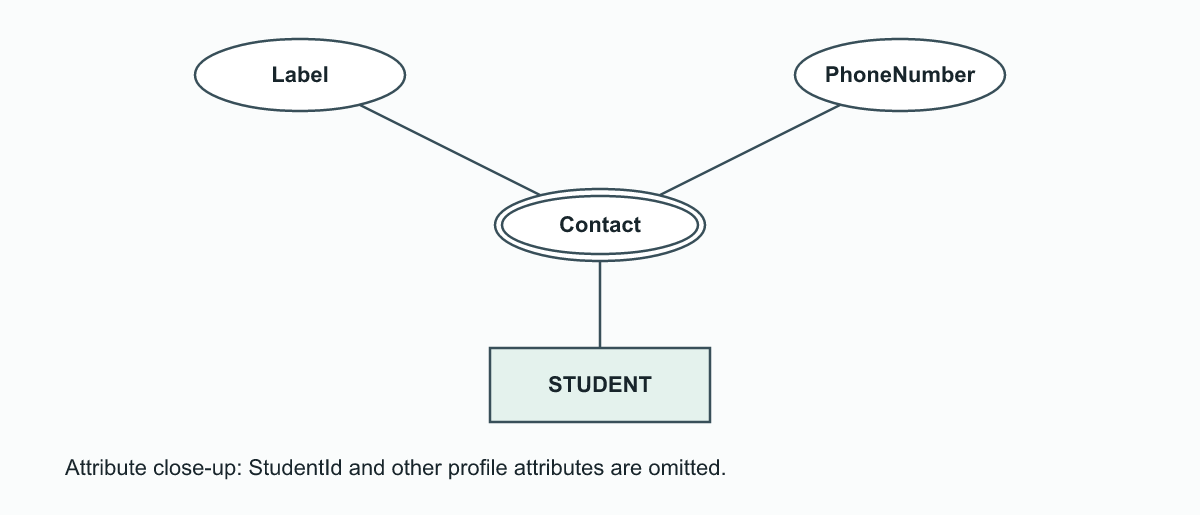

One Contact value is a Label-PhoneNumber pair. The double oval permits several such pairs for one student.


### Read the Contact Example

There is one student with two Contact values. The home value contains Label
and PhoneNumber; the mobile value contains those same two components.
The double oval expresses several values. The component ovals express the
structure of each value. Neither property implies the other.

| If the requirements change | Symbol that changes | What stays the same |
|---|---|---|
| Keep at most one labeled contact | Contact becomes a single oval. | Each value still has Label and PhoneNumber. |
| Keep several numbers but no labels or components | Use a double Phone oval with no component ovals. | Several values are still allowed. |

**Practice:** Draw Contact for two invented (Label, PhoneNumber) pairs.
Then change the requirements so that only one phone may be recorded per student.
Check which multiplicity symbol changes; composite structure and multiplicity
must not be treated as the same property. This profile is an explanatory variant;
the final core diagram retains only StudentId and Phone.


## 4. Keys Identify Entities

A **key attribute** has a value that uniquely identifies every entity in each
legal state of the entity set. A key can be composite. Its components must be
needed together; adding an unnecessary component does not produce a minimal key.

Uniqueness in a few sample records is not enough to establish a key.
Two students may have different names today, but the requirements allow future
students to share a name. StudentId is a key because the rule requires uniqueness.

For a separate campus-room example, assume a room number is unique only within
its building:

| Building | RoomNo |
|---|---:|
| A | 101 |
| A | 102 |
| B | 101 |

**Prediction:** Does RoomNo alone identify a room? Does Building alone?
Which combination distinguishes all rooms under the stated rule?


### One composite key is not two separate keys

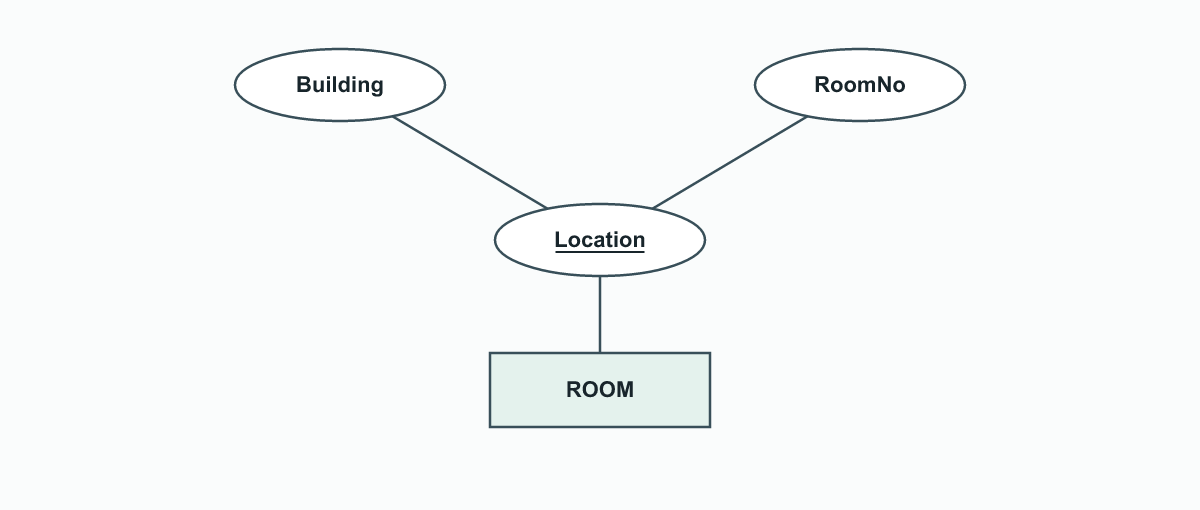

Underline Location, not Building and RoomNo separately. Neither component identifies a room alone.


### Read the Diagram

RoomNo 101 occurs twice; Building A also occurs twice. The composite
Location(Building, RoomNo) identifies a room, and removing either component
loses that guarantee. Underline the composite Location oval.

In the book's ER notation, separately underlining Building and RoomNo would
claim that each is a key independently. That would be wrong here.
An entity type may have more than one independent key if the requirements
guarantee each. This ER presentation does not select a "primary key";
that choice belongs to the relational model and mapping chapters.


### Worked Example: Find One Room

Use the same three rooms: A/101, A/102, and B/101. Read each lookup in the
next table independently. A slash separates Building and RoomNo for reading.

**Prediction:** How many rooms remain when only 101 is supplied? How many remain
when both A and 101 are supplied?


### How many rooms match the information supplied?

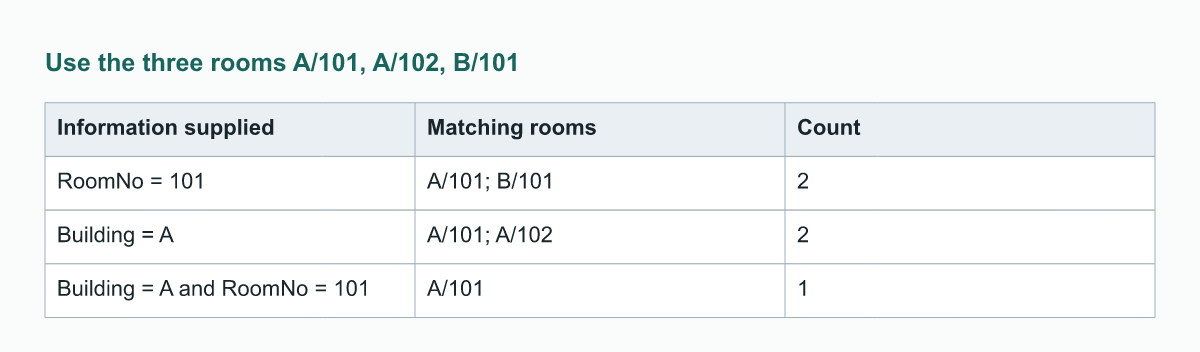

Building and RoomNo work together. The stated rule, not this small sample alone, guarantees that Location is a key.


### Read the Room Lookup

RoomNo 101 leaves two candidates. Building A also leaves two. Together A and
101 leave exactly one. This shows why both components are needed in this
example. The rule that room numbers are unique within buildings establishes
the guarantee for future states; three rows alone cannot establish that rule.

**Practice:** Suppose rooms receive a new RoomId unique across all buildings,
while the Location rule remains. Draw both valid keys. Check that you have not
turned two independent keys into one larger composite key.


## 5. Domains and Missing Values

A **value set**, or **domain**, specifies allowed values of an attribute.
It is not simply the values currently present.

For an expanded COURSE description, assume Credits must be a whole number
from 1 through 6. The two observed courses currently have 2 and 3 credits.
A proposed value of 5 is still legal. A value of 2.5 fails the whole-number
condition, and 7 exceeds the limit. These are example rules, not university policy.

Missing information also needs a meaning. The book uses **NULL** for information
that is unknown or not applicable. A grade may be unknown because marking is
unfinished. In a separate staff profile, ParkingPermitNo may be inapplicable
because the person has no permit. Not knowing whether a permit exists is
different from knowing that none exists.

**Prediction:** Is 5 rejected because it is absent from today's sample?
Can an unrecorded grade automatically be interpreted as zero?


### Allowed values are not just the observed values

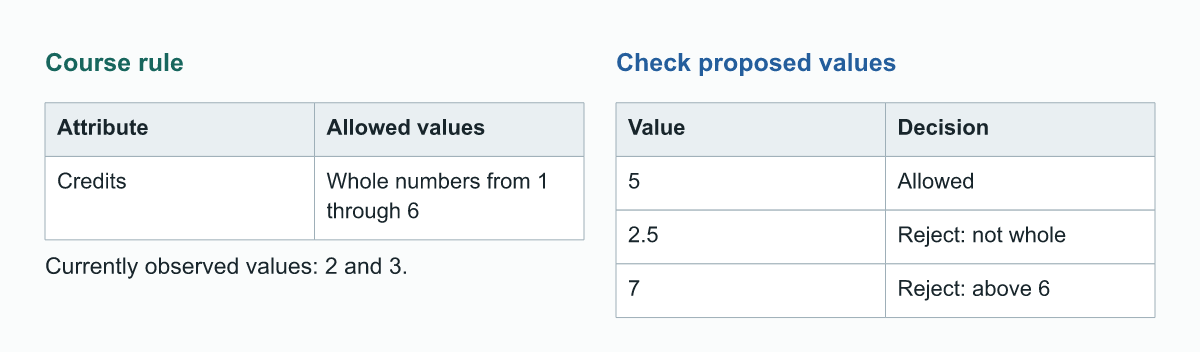

Under this example's rule, 5 is allowed even though only 2 and 3 occur in the current courses.


### Read the Diagram

Five satisfies the declared domain. The displayed rejected values violate
specific conditions, not merely an observed pattern. An unrecorded grade is
not evidence of a score of zero.

"No phone recorded" likewise does not prove that a student owns no phone.
A conceptual explanation can distinguish reasons for missing information.
The later SQL chapter will discuss what SQL NULL operations actually do.


### Worked Example: Missing Is Not Zero

Compare four separate fictional cases. A recorded grade of zero is known data.
An unfinished grade and two absent permit numbers require different explanations.

**Prediction:** Which case supports a numeric zero? Which case establishes that
no permit exists, rather than leaving that question unanswered?


### Similar empty entries can have different meanings

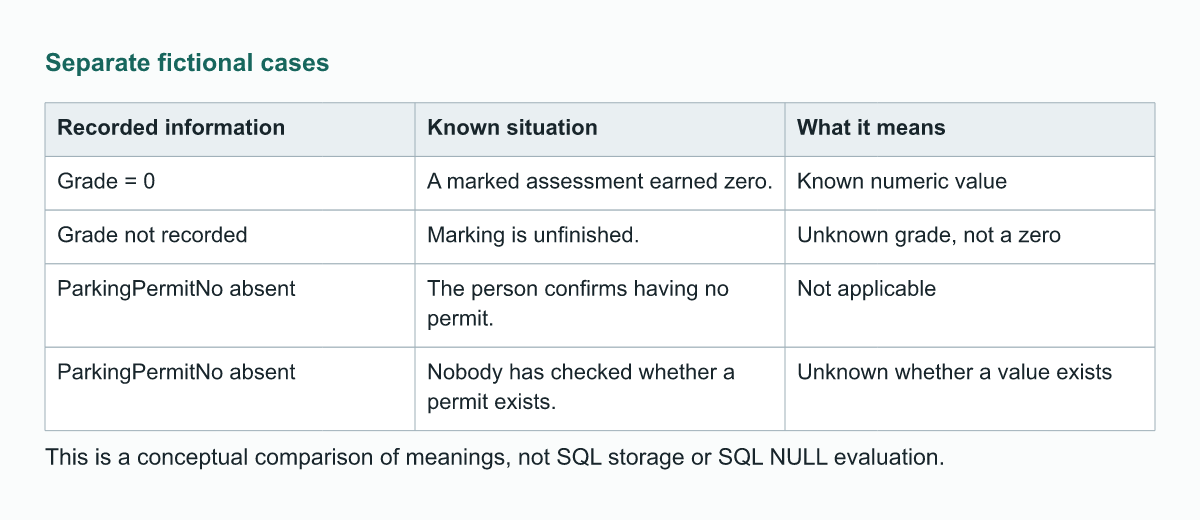

Do not replace missing information with zero or with a claim that no value exists. First establish what is known.


### Read the Missing-Value Cases

Only the marked assessment supports Grade = 0. Unfinished marking does not.
A confirmed absence of a permit makes its number inapplicable. An unchecked
permit status leaves open whether a number exists. The table supplies these
reasons explicitly; an empty entry by itself does not distinguish them.

**Practice:** Check proposed Credits values 1, 6, 0, and 3.5 against both
conditions. For an absent advisor name, write two different possible reasons
and one question that distinguishes them. Keep the reason separate from a
claim about how a DBMS stores it.


## 6. Relationships Connect Entities

A **relationship instance** associates particular participating entities.
An enrollment connecting S101 to the section DB101 / 1 is one instance.
**ENROLLS_IN** is the relationship type; its current **relationship set**
contains the enrollment instances currently recorded.
Draw a relationship type as a diamond connected to its participating entity
types. These lines are undirected connections, not a sequence of actions.

The slash notation DB101 / 1 identifies a section by course and section number
for human reading. It is not a foreign-key declaration. Section 12 explains
why this identity needs both parts.

| Student | Section | Grade |
|---|---|---:|
| S101 | DB101 / 1 | 80 |
| S101 | CS102 / 1 | 90 |
| S102 | DB101 / 1 | 70 |

The **degree** counts participating roles. This relationship is binary because
each enrollment connects a student and a section. The number of attributes
or the number of current enrollment facts does not determine its degree.

**Prediction:** How many enrollment instances are shown? How many involve S101?
Does S103's absence mean that S103 must be deleted from STUDENT?


### An enrollment connects a student to a section

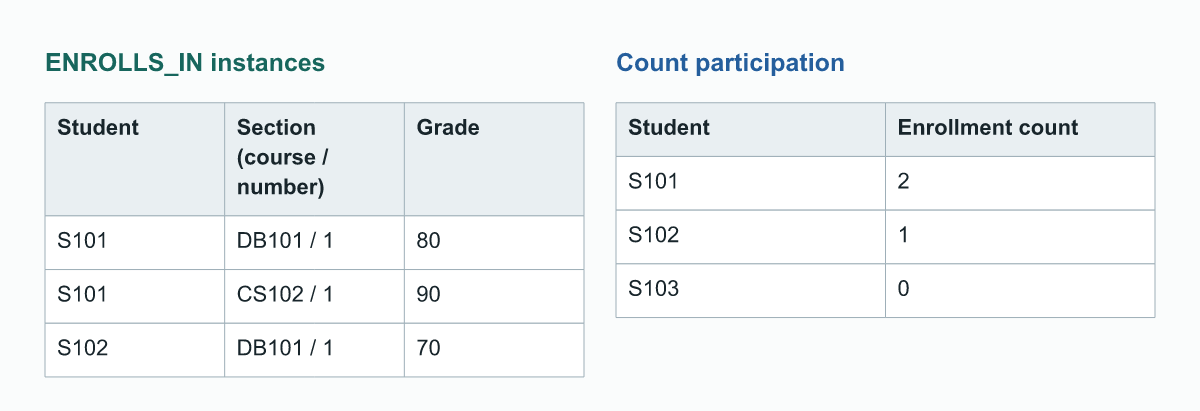

The three rows describe three relationship instances, not three relationship types.


### Read the Diagram

There are three enrollment instances; two involve S101 and none involves S103.
The requirements allow students with no enrollment, so S103 may remain.
The relationship set is separate from the entity set.


### Worked Example: Trace the Three Enrollments

The next picture draws the same three enrollment facts as lines between
individual objects. These labeled boxes are not entity-type rectangles in
an ER schema. Grade is deliberately left out of this connection-only view.
One student may attend several sections, and one section may contain several
students. This is a **many-to-many (M:N)** relationship; Section 7 compares it
with the other maximum-cardinality patterns.

**Prediction:** Count the lines touching S101, S103, and DB101 / 1.


### M:N: follow each recorded enrollment line

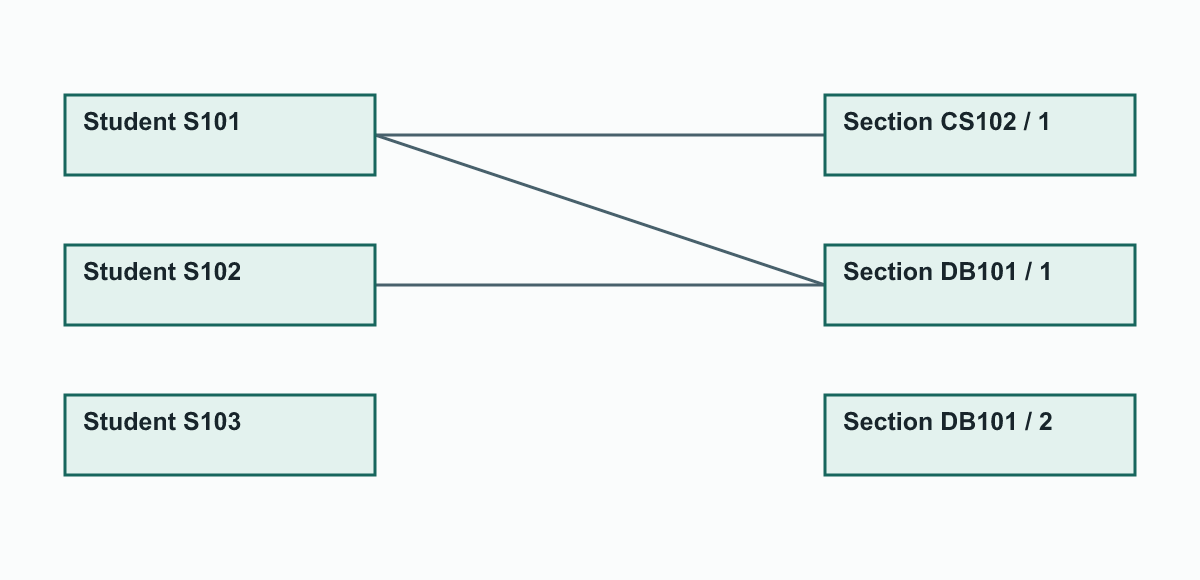

These boxes are individual objects, not ER type symbols. Each line is one enrollment; Grade is omitted in this connection-only view.


### Read the Enrollment Lines

S101 touches two lines, S103 touches none, and DB101 / 1 touches two.
The unconnected student and DB101 / 2 still exist. A student can share a section
with another student while also attending another section: this is an allowed
M:N state. The requirements, not this picture alone, define the maximum ratio.

| Isolated change to the original facts | All enrollment instances | S101 count | S103 count |
|---|---:|---:|---:|
| No change | 3 | 2 | 0 |
| Remove S101's CS102 / 1 enrollment | 2 | 1 | 0 |
| Instead add S103's DB101 / 2 enrollment | 4 | 2 | 1 |

The second row also explains a derived attribute: S101's EnrollmentCount
changes from 2 to 1 without changing S101's identity or recorded phones.
The third row starts from the original three facts, not from the second row.

**Practice:** Add an enrollment linking S103 to DB101 / 2, with the grade not
yet known. Recount instances and each student's participation. Check that you
added a relationship instance, not a new student entity or relationship type.


## 7. Maximum Cardinality

The **cardinality ratio** of a binary relationship restricts its maximum
participation pattern. Read the requirements in both directions.

| Relationship | Rule for one object on the left | Rule for one object on the right |
|---|---|---|
| STUDENT HOLDS CARD, a separate variant | At most one card | At most one student |
| INSTRUCTOR TEACHES SECTION | May teach several sections | At most one instructor |
| STUDENT ENROLLS_IN SECTION | May enroll in several sections | May contain several students |

These give 1:1, 1:N, and M:N respectively. M and N mean that the diagram gives
no fixed numeric upper bound on that side; they do not require every entity
to participate many times.

**Prediction:** I1 teaches DB101 / 1 and DB101 / 2. Which maximum rule would
be violated if I2 also taught DB101 / 1 in this example?


### Compare maximum counts in both directions

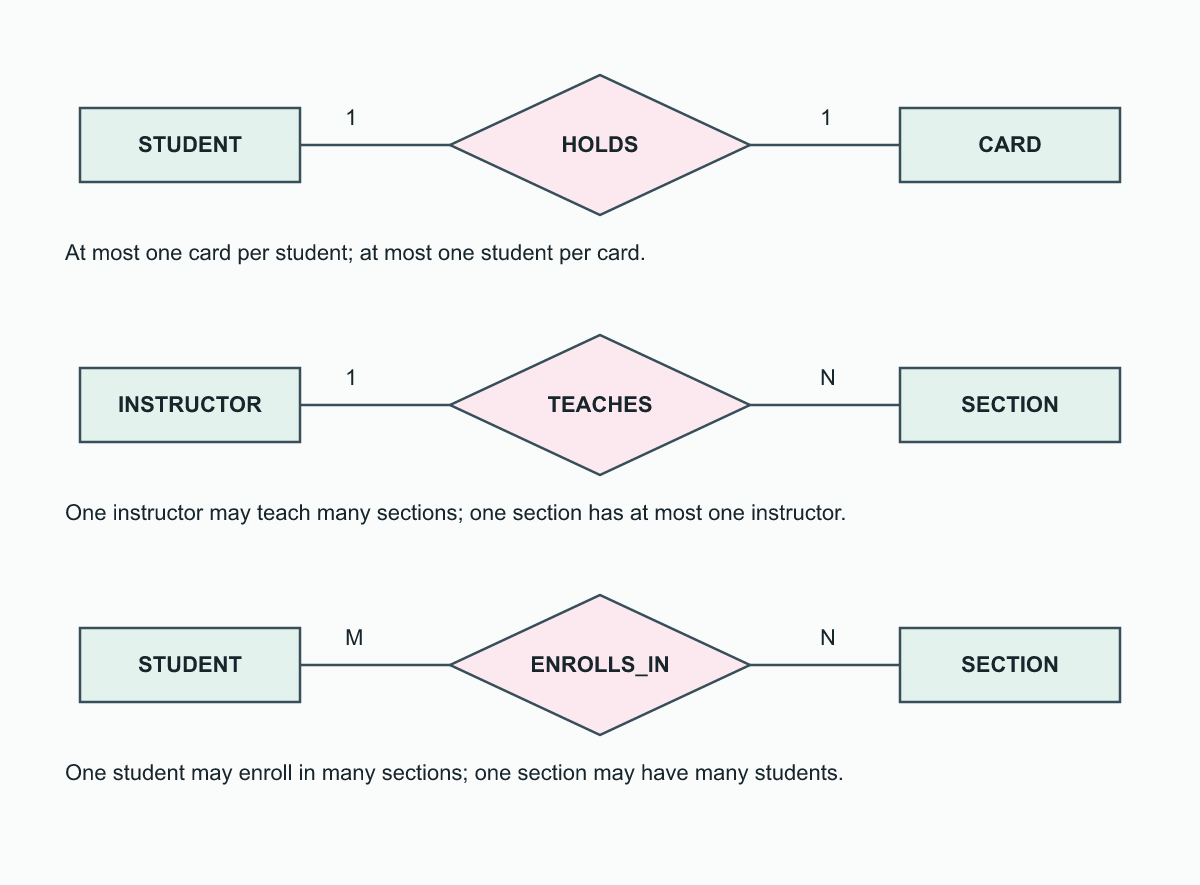

These panels isolate maximum ratios. Participation requirements are added in the next figure.


### Read the Diagram

One section would have two instructors, violating its maximum of one.
I1 teaching two sections does not violate the rule.

In the book's maximum-ratio notation, the 1 near INSTRUCTOR means that one
SECTION has at most one instructor. The N near SECTION permits an instructor
to teach many sections. Follow the whole relationship rather than reading the
nearest numeral as that entity's own participation count. Section 9 introduces
a different placement convention.

The three panels isolate the maximum counts. Participation requirements are
added next. Relationship close-ups omit keys and weak-entity markings until
Section 12 explains identification; Section 15 combines the symbols.
A small state with one instructor and one section does not prove
the relationship is 1:1; permitted future states matter.


### Worked Example: One Card or Several Sections

Compare two separate snapshots. In the card variant, S101 holds K10 and S102
holds K11; S103 holds no card. In the teaching snapshot, I1 teaches DB101 / 1
and DB101 / 2, while I2 teaches CS102 / 1. Each line represents one recorded fact.

**Prediction:** Which objects have two lines? Would adding S102-K10 pass the
card maximum? Would adding I2-DB101 / 1 pass the teaching maximum?


### 1:1: no object has more than one HOLDS line

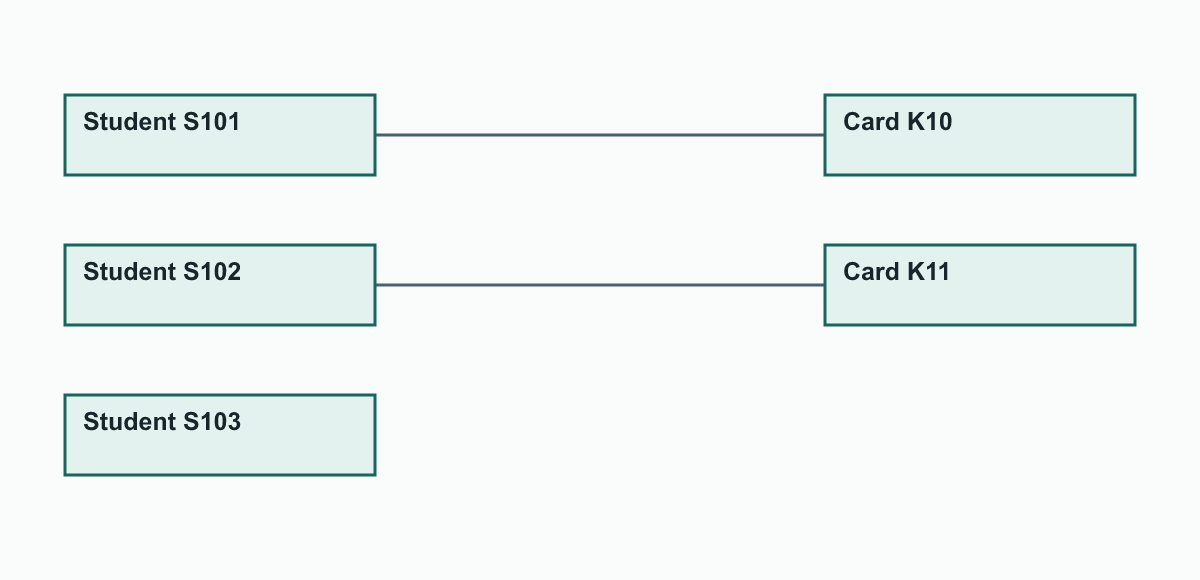

Objects, not ER type symbols. This separate variant allows at most one card per student and at most one student per card; it does not require a line.


### 1:N: I1 has two lines; each section has one

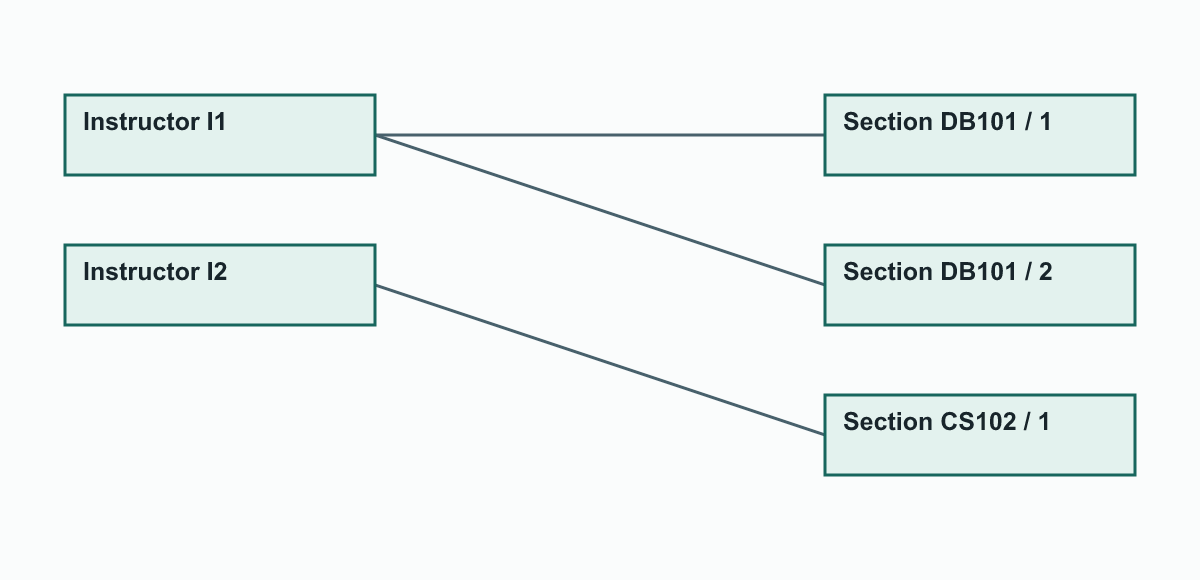

Objects, not ER type symbols. I1 teaching two sections is allowed. A second instructor on either section would violate its maximum of one.


### Read the Two Snapshots

Only I1 has two lines. Both proposed additions fail: K10 would have two students,
and DB101 / 1 would have two instructors. I1's two sections are allowed.

| Pattern | Follow one object on the left | Then follow one object on the right |
|---|---|---|
| HOLDS, 1:1 variant | S101 has one card; at most one is allowed. | K10 has one student; at most one is allowed. |
| TEACHES, 1:N | I1 has two sections; several are allowed. | DB101 / 1 has one instructor; at most one is allowed. |
| ENROLLS_IN, M:N | S101 has two sections; several are allowed. | DB101 / 1 has two students; several are allowed. |

Zero lines is not decided by a maximum alone. These snapshots show permitted
counts; the next section supplies minimum participation requirements.

**Practice:** For a team-teaching variant, allow several instructors per section
while each instructor may still teach several sections. Redraw only the maximum
ratio. Check your drawing using two instructors connected to the same section.


## 8. Total and Partial Participation

A **participation constraint** specifies whether every entity must participate.
**Total participation** requires at least one relationship instance for each
entity of the participating type. **Partial participation** permits zero.

The final TEACHES rule is stronger than "at most one": each section must have
exactly one instructor. SECTION therefore has total participation.
INSTRUCTOR has partial participation because an instructor can teach no section.

**Prediction:** Is a new instructor I3 with no teaching assignment allowed?
Is a new section with no instructor allowed?


### A double line requires participation

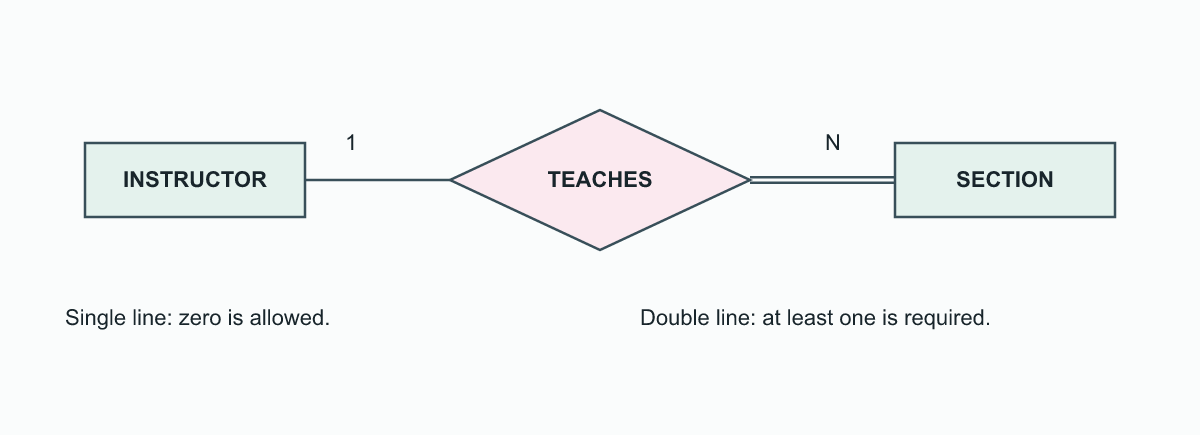

Every SECTION must have a teacher. An INSTRUCTOR may currently teach no section.


### Read the Diagram

I3 is allowed; the unassigned section is not. The double line from SECTION
to TEACHES expresses the minimum of one. The maximum ratio supplies the
upper bound of one instructor per section. These are different constraints.

Partial participation does not require an unassigned instructor to exist in
every current state. It merely permits one. Total participation does not by
itself make an entity weak: a CARD with its own globally unique CardNo can
require an owner without depending on the owner's key for identification.


### Worked Example: Change One Fact at a Time

Begin with the original assignments: I1 teaches DB101 / 1 and DB101 / 2;
I2 teaches CS102 / 1. Test each proposal separately against those facts.
Keep all three sections and their owning courses unless the proposal says otherwise.

**Prediction:** Which proposal fails because a count becomes zero? Which fails
because a count becomes two? Does changing a teacher necessarily break the rule?


### A minimum and a maximum reject different changes

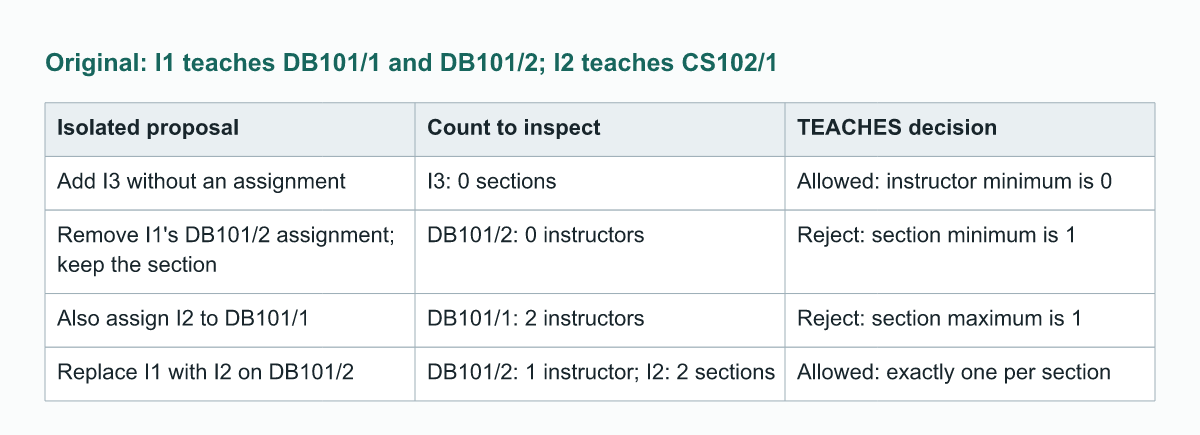

Each proposal starts from the original three assignments. A section's owner course remains present; the table checks TEACHES only.


### Read the Assignment Changes

Removing DB101 / 2's only teaching assignment gives it zero instructors and
fails the minimum. Adding I2 to DB101 / 1 without removing I1 gives that section
two instructors and fails the maximum. Replacing I1 with I2 on DB101 / 2 leaves
one instructor there, so it passes this relationship's constraints. Adding I3
without any assignment also passes because instructors may teach none.
These are checks of completed proposed states, not a lesson about SQL update order.

**Practice:** Change the rule to require every instructor to teach at least
one section, without changing the maximum counts. Mark the line that changes.
Then decide whether adding I3 alone would still be legal and cite the new rule.


## 9. Read Min-Max Labels Carefully

The book also presents **(min, max)** notation. A pair beside an entity type
counts how many relationship instances **one entity of that type** participates in.

For TEACHES, put (0,N) beside INSTRUCTOR and (1,1) beside SECTION.
This represents the same requirements as the preceding complete TEACHES diagram.
The pair supplies both minimum and maximum, so this figure uses single
connection lines instead of the earlier single/double participation convention.

**Prediction:** Does (1,1) beside SECTION mean one student per section or
one TEACHES instance per section?


### Place this notation beside the entity being counted

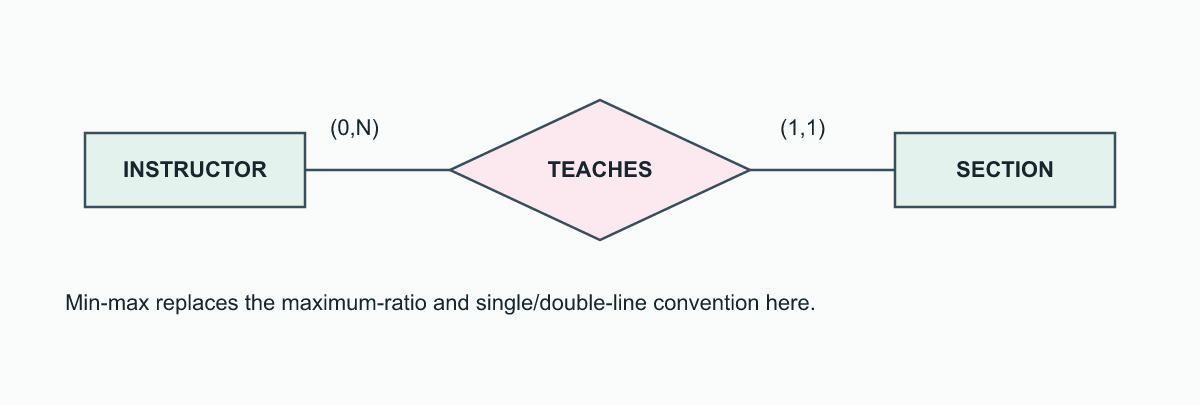

Here (0,N) counts sections for one instructor; (1,1) counts teachers for one section.


### Read the Diagram

It means exactly one TEACHES instance per section: one instructor.
It says nothing about ENROLLS_IN or the number of students.

Do not copy the positions of 1 and N from the maximum-ratio diagram into
min-max pairs. The two notations place their counts differently.
UML also has its own placement convention; do not silently mix it into this ER diagram.


### Worked Example: Count First, Then Choose the Label

Inspect I1 and DB101 / 1 in the unchanged teaching snapshot. I1 has two
TEACHES instances. DB101 / 1 has one. The next table translates the same
requirements between the two binary notations.

**Prediction:** Is (1,1) placed beside INSTRUCTOR or SECTION when one section
must have exactly one instructor?


### The same TEACHES counts, written in two notations

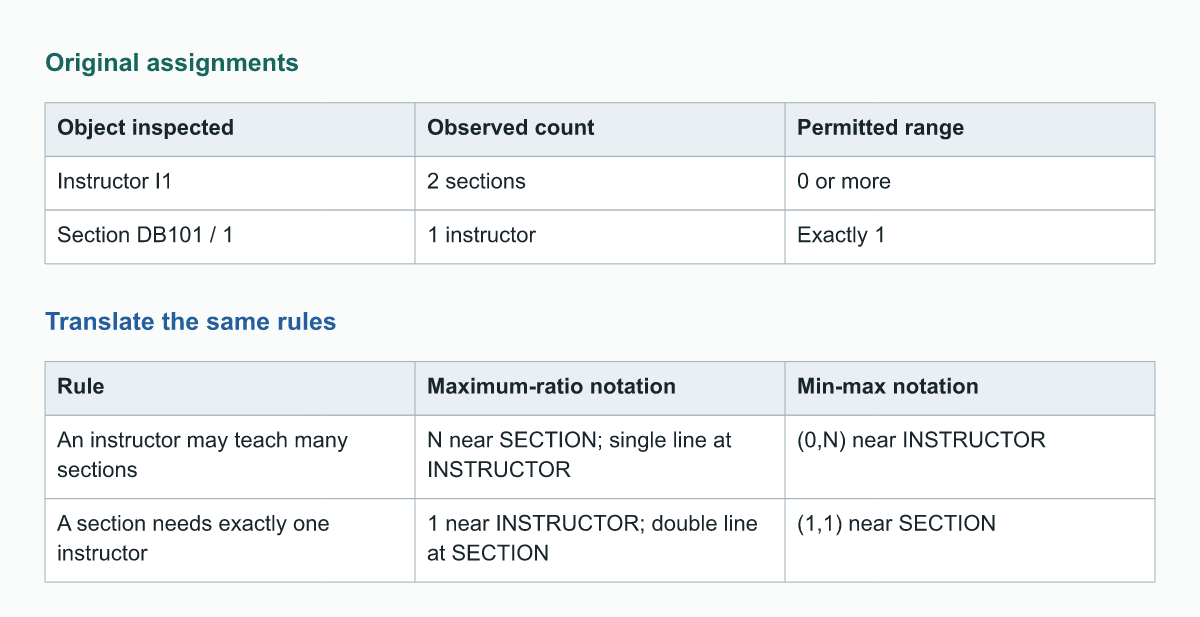

For a binary relationship, maximum-ratio labels refer across the connection. A min-max pair is placed beside the entity being counted.


### Read the Notation Comparison

Place (1,1) beside SECTION: that is the entity whose participation is counted.
In maximum-ratio notation, the corresponding upper-bound 1 is near INSTRUCTOR,
across the relationship from the section being inspected. The SECTION double
line supplies the minimum. Do not move labels without translating their meaning.

**Practice:** An instructor must teach at least one and at most three sections.
Write the new pair beside INSTRUCTOR and test counts 0, 1, 3, and 4.
Keep SECTION's rule unchanged. Your check should name both accepted and rejected counts.


## 10. Recursive Relationships and Roles

A **recursive relationship** connects entities of the same type in different
**roles**. For a separate mentoring variant, one student may mentor several
students, and a student may have at most one mentor. Both roles permit zero.

| Mentor | Mentee |
|---|---|
| S101 | S102 |
| S101 | S103 |

MENTORS is binary even though only one entity-type rectangle is needed.
Each instance has a mentor participation and a mentee participation.

**Prediction:** Could the same two names in reversed order describe a different
mentoring fact? Which role has two participations in this sample?


### One entity type can participate twice

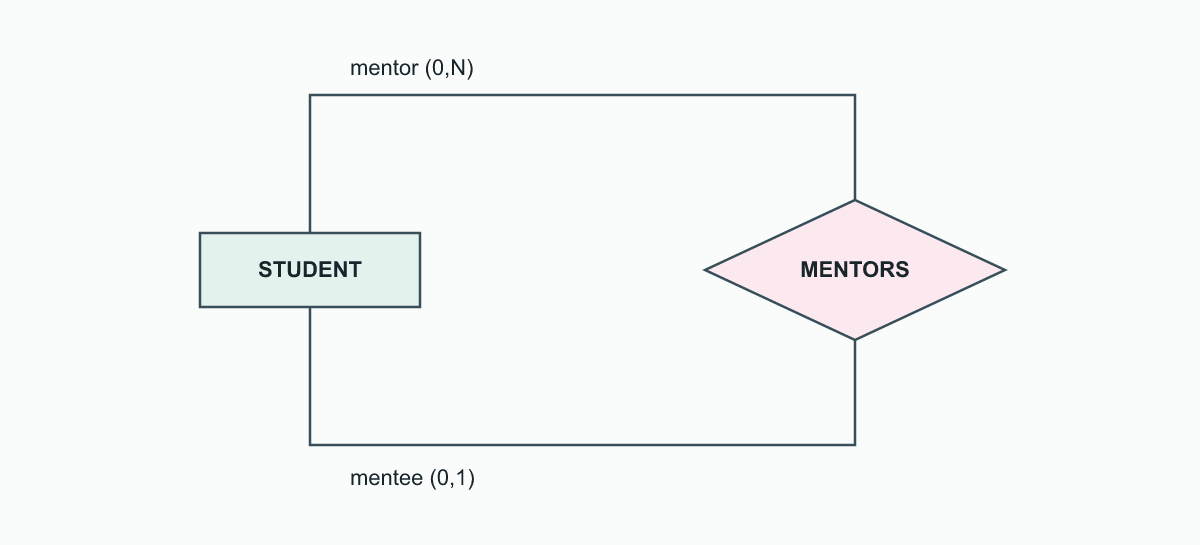

MENTORS is binary because it has two roles: mentor and mentee. These counts alone do not forbid self-mentoring.


### Read the Diagram

S101 is the mentor in two instances. Reversing the names reverses the roles;
S102 mentoring S101 is not the same fact as S101 mentoring S102.
The two lines connect the same type to different roles of the same relationship,
not two different student types.

If the application forbids self-mentoring or cycles, write those as additional
rules. The displayed min-max constraints alone do not prohibit either.
Two roles do not by themselves require two different students. For example,
(S101, S101) would use S101 in both roles; forbidding it needs a separate rule.


### Worked Example: Follow the Named Roles

Display the same three students twice, once for each role. The two recorded
facts remain S101 mentoring S102 and S101 mentoring S103. A repeated StudentId
refers to the same student, not to a second entity.

**Prediction:** Does S101 appear as a mentee in either fact? If the first pair
were reversed, whose mentor participation would increase?


### Read each line from mentor role to mentee role

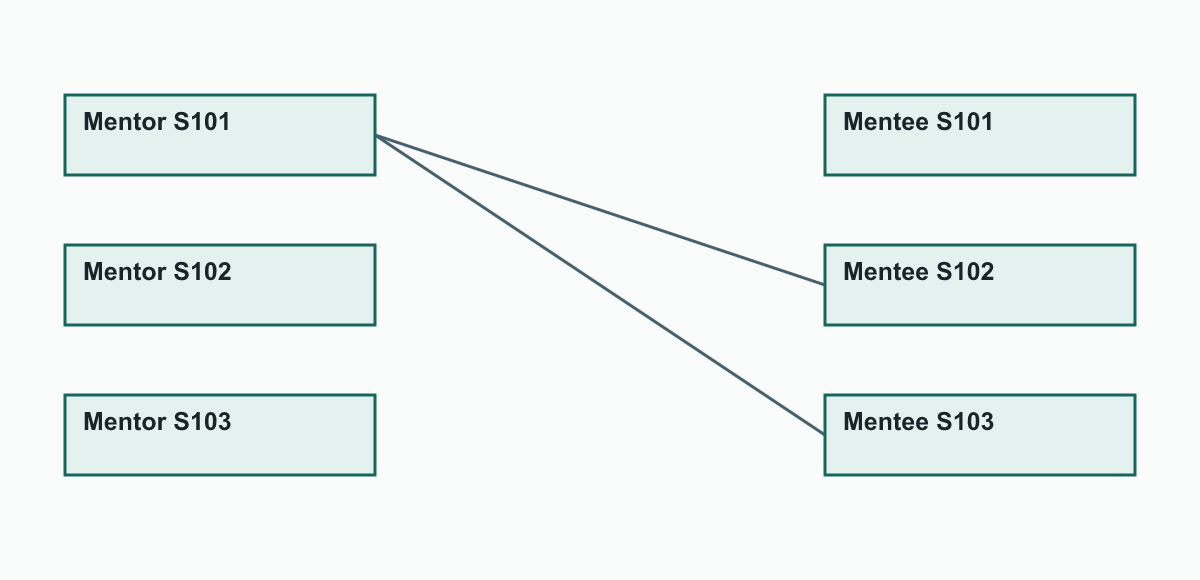

Both columns use the same STUDENT set. Repeating S101 does not create a second student. The named roles, not an arrow, determine each fact.


### Read the Role Columns

S101 has two participations as mentor and zero as mentee. Replacing the first
fact with S102 mentoring S101 would give S102 one mentor participation and
S101 one mentee participation. The order of the named roles changes the meaning.

| Student | Mentor participations in the original facts | Mentee participations in the original facts |
|---|---:|---:|
| S101 | 2 | 0 |
| S102 | 0 | 1 |
| S103 | 0 | 1 |

This is one STUDENT set participating in two roles of one binary relationship,
not two entity types and not a ternary relationship.

**Practice:** Add S102 as mentor of S103 and inspect S103's mentee participation
count. Separately consider S101 mentoring S101. Identify which question can be
answered by the displayed counts and which needs an additional business rule.


## 11. Attributes of a Relationship

An attribute can describe a relationship instance rather than one participating
entity. Grade belongs to an enrollment: it needs both the student and the section.

| Student | Section | Grade |
|---|---|---:|
| S101 | DB101 / 1 | 80 |
| S101 | CS102 / 1 | 90 |
| S102 | DB101 / 1 | 70 |

**Prediction:** Can one Grade value attached to S101 represent both of S101's
grades? Can one Grade attached to DB101 / 1 represent both of that section's grades?


### A grade belongs to a particular enrollment

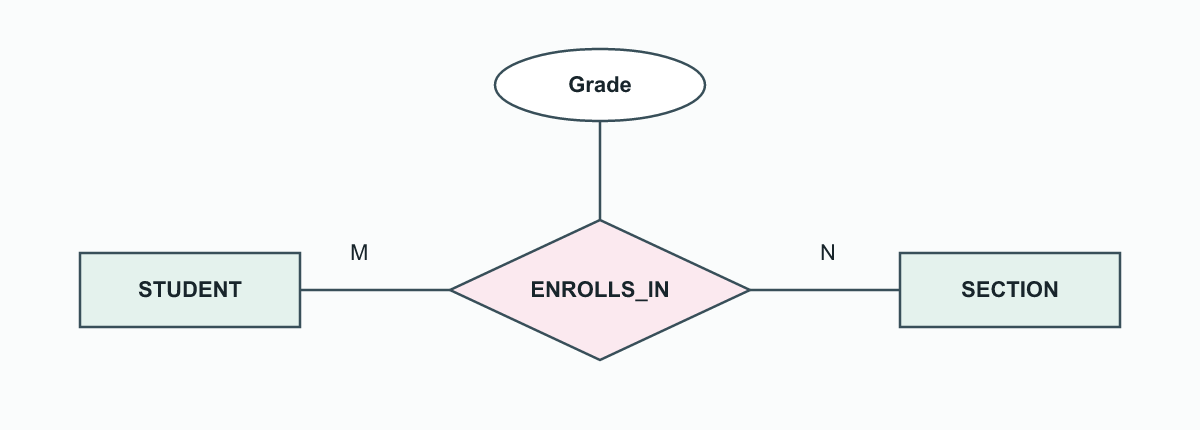

S101 has 80 in DB101 / 1 and 90 in CS102 / 1. One grade on STUDENT cannot describe both.


### Read the Diagram

Neither single value is enough. S101 has 80 and 90; DB101 / 1 has grades
80 and 70 for different students. The Grade oval connects to ENROLLS_IN.

The argument depends on these M:N facts. It does not establish that every
relationship attribute must always remain on a relationship: under suitable
1:N or 1:1 constraints, an attribute can be placed on an entity without losing
which relationship instance it describes.


### Worked Example: Read a Grade at the Intersection

Arrange the original three facts with students on rows and sections on columns.
The entries show grades only where an enrollment exists. This display is for
reasoning; it is not a proposed relational schema.

**Prediction:** Read S101's row and then DB101 / 1's column. Does either contain
only one grade that could describe all its enrollments?


### Choose a student AND a section before reading Grade

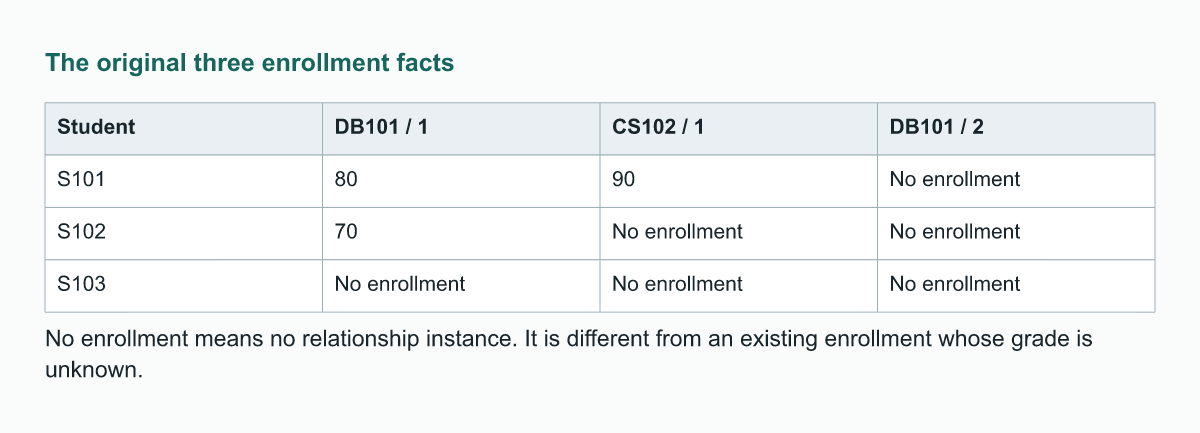

S101's row contains 80 and 90. DB101/1's column contains 80 and 70. Neither participant alone determines Grade in this M:N example.


### Read the Grade Matrix

S101's row has 80 and 90. DB101 / 1's column has 80 and 70. Choose both a row
and a column to locate a grade: S102 together with DB101 / 1 gives 70.
Putting just one grade on either entity would lose which enrollment it describes.

| State of S103 and DB101 / 2 | Relationship instance exists? | Grade information |
|---|---|---|
| Original facts | No | No grade for this nonexistent enrollment |
| Separate variant: S103 enrolls, marking unfinished | Yes | Unknown, not zero |
| Same variant after a recorded grade of 0 | Yes | Known grade of 0 |

These three situations must not be represented as though they meant the same thing.

**Practice:** Suppose each enrollment records a submission status, such as
"submitted" or "not submitted." Place the attribute and construct two facts
showing why attaching it to STUDENT alone could lose information.
Check that your two facts involve the same student and different sections.


## 12. Weak Entities and Partial Keys

A **weak entity type** lacks a complete identifying key of its own.
An **owner entity type** supplies part of its identification through an
**identifying relationship**. A **partial key** distinguishes weak entities
belonging to the same owner or owner combination. Weak types normally have a
partial key; a later example explains when the owners alone suffice.

For this one-term example, SECTION has no globally unique SectionId:

| Owning COURSE | SectionNo | Section identified |
|---|---:|---|
| DB101 | 1 | DB101 / 1 |
| DB101 | 2 | DB101 / 2 |
| CS102 | 1 | CS102 / 1 |

**Prediction:** Are the two occurrences of SectionNo 1 an error?
Would a second section numbered 1 under DB101 be allowed?


### A section needs its owner to be identified

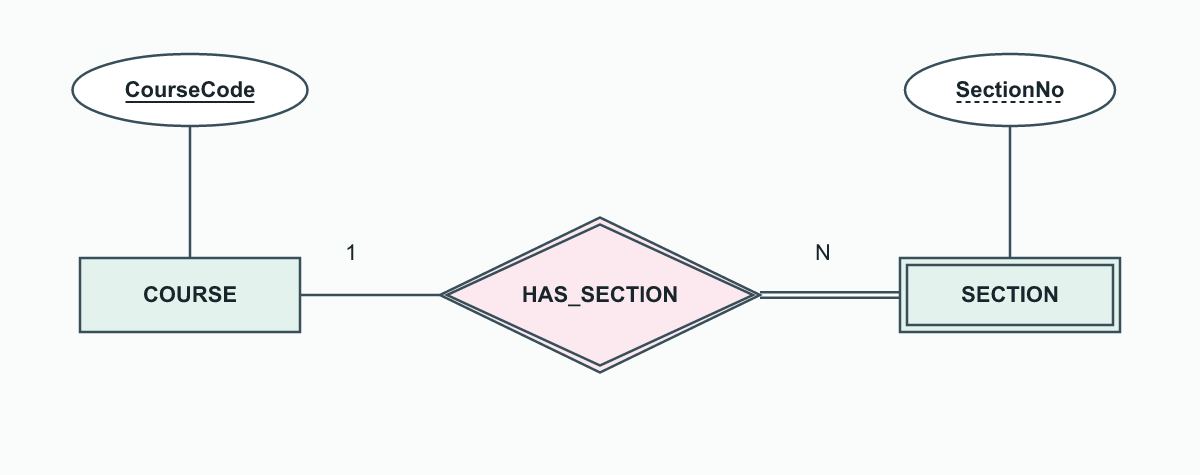

Within Fall 2026, COURSE plus SectionNo identifies SECTION. SectionNo alone can repeat across courses.


### Read the Diagram

SectionNo 1 is allowed under different courses. A second such section under
DB101 would not be distinguishable by the declared identity.
COURSE is the owner; SectionNo is the partial key.

The weak type uses a double rectangle. HAS_SECTION uses a double diamond.
The partial key has a dashed underline. SECTION participates totally in its
identifying relationship because it cannot be identified without an owner.

Existence dependence alone is insufficient: an object with its own complete
key need not be weak even when it must have an owner.
If we later keep several terms, (course, section number) may no longer distinguish
all sections. The term must enter the identification, or the requirements must
provide another complete identifier. The current example deliberately keeps one term.

**Practice:** Add CS102 / 2 and then propose a second DB101 / 2.
Explain the different outcomes. Next propose a globally unique SectionId and
identify which weak-entity symbols would no longer describe that revised choice.
Do not create relational tables yet.


### 12.1. Order Items: the Same Number under Different Owners

Consider orders for a fictional campus store. OrderId identifies an order.
Each order numbers its items from 1. LineNo is unique within that order;
an item has no separate ItemId. Quantity is recorded but does not identify an item.
Product is the recorded product name in this small example, not a separate
product entity or an identifier for the order item.

| OrderId | LineNo | Product | Quantity |
|---|---:|---|---:|
| O10 | 1 | Notebook | 2 |
| O10 | 2 | Pen | 3 |
| O20 | 1 | Notebook | 2 |

**Prediction:** Are O10 / 1 and O20 / 1 the same item because their product,
quantity, and line number match?


### An item number identifies an item only within its order

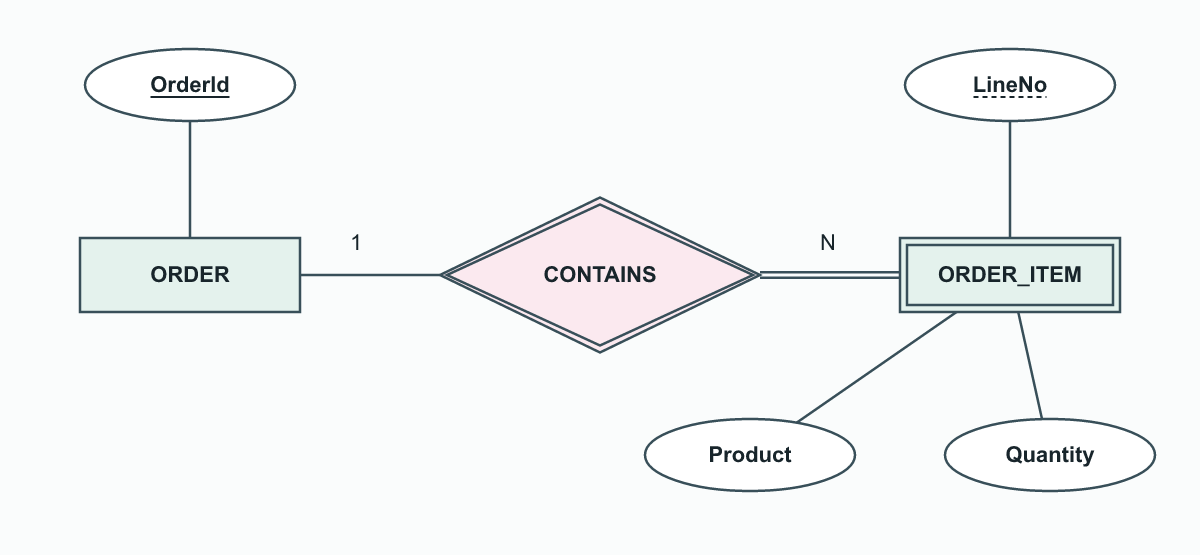

O10 / 1 and O20 / 1 are distinct items. Product and Quantity describe an item; neither is its partial key.


### Read the Order Item Diagram

They are different order items because their owners differ. Follow three steps:
identify the order, find LineNo within that order, then read the item's properties.
The full identifying information is (OrderId, LineNo). LineNo is only a partial key.
A fourth item with O10 / 1 would violate the stated identification rule.
The Product and Quantity ovals both attach to ORDER_ITEM. The table's OrderId
comes from the owning ORDER; it is not an extra attribute oval on ORDER_ITEM.

The double rectangle marks ORDER_ITEM; the double diamond marks CONTAINS.
Every item must participate in CONTAINS, but an order may have no items while
being prepared. That optional order participation is an explicit example rule.


### Worked Example: Find the Owner Before the Item

Use exactly the three order items above. Compare the candidates remaining
when an item is described by its line number, its product and quantity,
its owner, or its owner together with its line number.

**Prediction:** Can the description "Notebook, quantity 2, line 1" distinguish
O10 / 1 from O20 / 1?


### Repeated properties do not make two order items identical

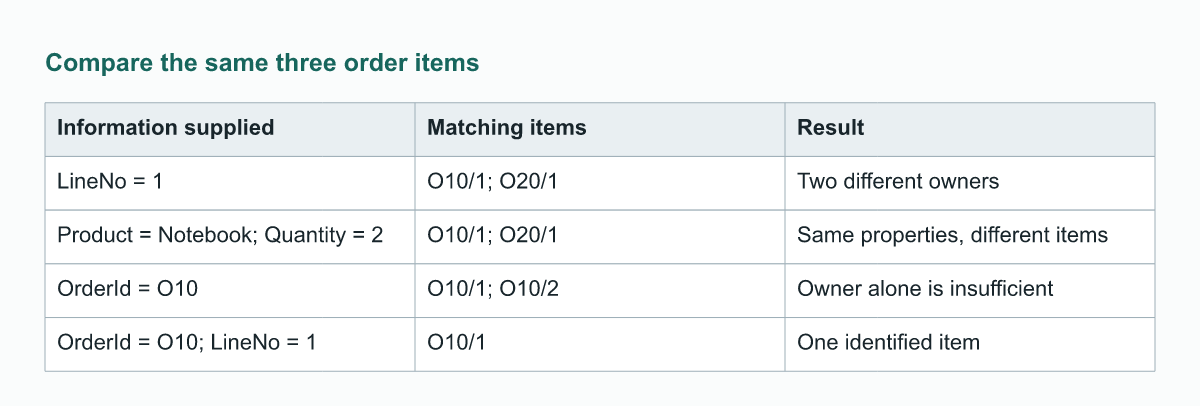

Start with the owner, then use its partial key. Quantity and Product describe the chosen item; they do not repair a duplicated identity.


### Read the Item Lookup

It cannot: both items have those three properties. Owner O10 removes O20 / 1
from consideration; LineNo 1 then distinguishes O10 / 1 from O10 / 2.
That is why the owner's identity and partial key are needed together.
Changing Quantity on a proposed second O10 / 1 would not create a new identity.

**Practice:** Add O20 / 2, then try adding another O10 / 2 with a different quantity.
Explain why changing Quantity cannot repair a duplicate identity.


### 12.2. A Required Owner Does Not Automatically Make an Entity Weak

Now consider campus access cards. CardId is unique across all issued cards.
Each card must belong to exactly one student; a student may have zero or several
cards. This is a separate variant from the earlier one-card maximum example.

| CardId | StudentId |
|---|---|
| K10 | S101 |
| K11 | S101 |
| K12 | S102 |

**Prediction:** Is CARD weak merely because a card without an owner is forbidden?


### CARD has its own key even when ownership is required

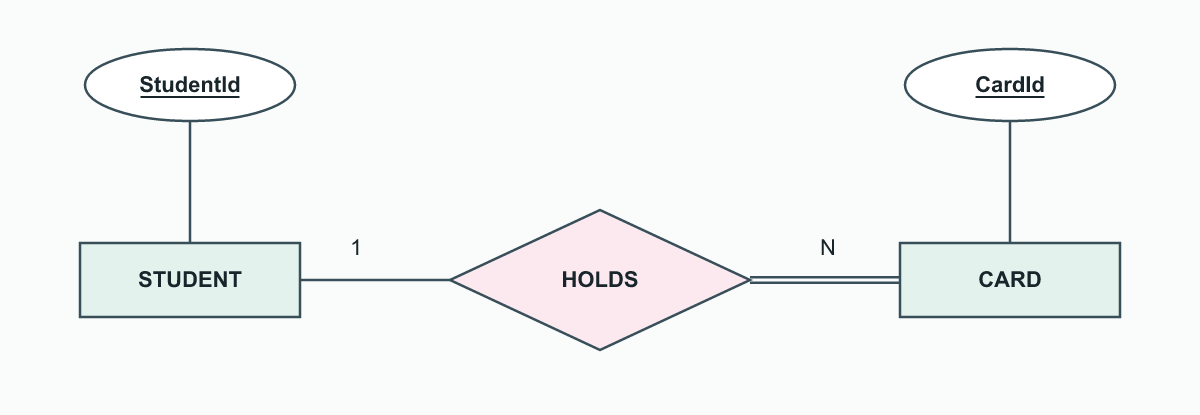

CardId is globally unique. A required owner changes participation, not this independent identification.


### Read the Card Diagram

CARD is a regular, or strong, entity type: CardId identifies a card independently.
Use a single rectangle and an ordinary relationship diamond. The double
participation line still applies to CARD because ownership is required.

Compare K10 with order item O10 / 1. K10 is already globally identifying.
The value 1 alone cannot identify an order item. The decisive question is
identification, not whether one object depends on another object's existence.

**Practice:** Remove the global CardId rule and number cards only within each
student. State the new identifying combination and which symbols must change.


### 12.3. A Weak Entity Can Own Another Weak Entity

Extend the order example to record notes about individual items. NoteNo is unique
within one order item; it may repeat for another item. ITEM_NOTE has no global ID.

| OrderId | LineNo | NoteNo | Note text |
|---|---:|---:|---|
| O10 | 1 | 1 | Gift wrap |
| O10 | 2 | 1 | Blue ink |
| O20 | 1 | 1 | No wrap |

**Prediction:** Is (LineNo, NoteNo) enough to identify the first and third notes?


### Follow identification through every owner

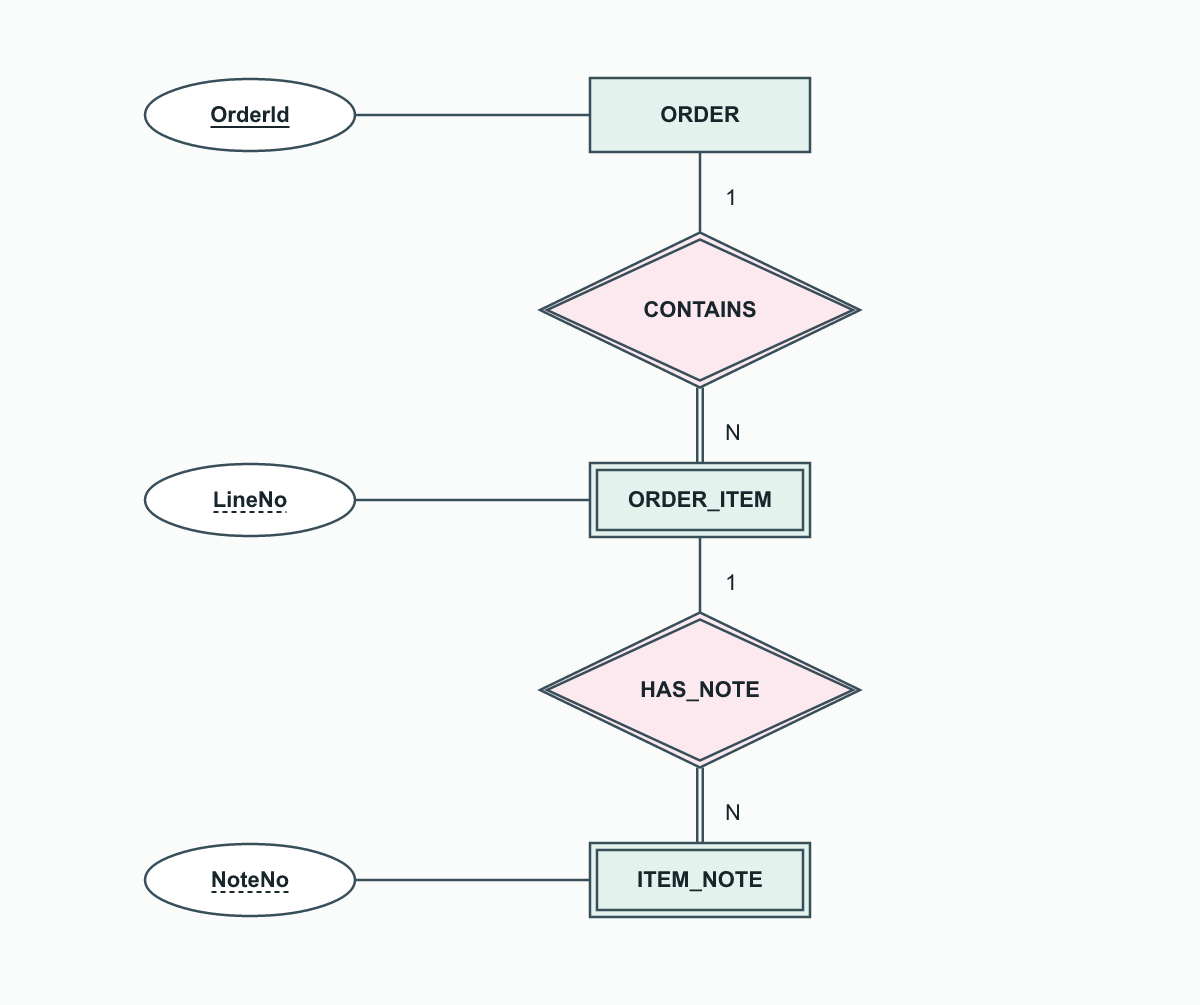

A note is identified by OrderId, LineNo, and NoteNo. ORDER_ITEM is both weak and an owner. Only identifying attributes are shown.


### Read the Nested Owner Diagram

No: both have (1,1). Identify ORDER with OrderId, then ORDER_ITEM with its owner's
identity plus LineNo, then ITEM_NOTE with that item's identity plus NoteNo.
The complete combination is (OrderId, LineNo, NoteNo).

ORDER_ITEM is both a weak entity and an owner of ITEM_NOTE. Both weak types
participate totally in their own identifying relationships. A parent item can
have zero notes; requiring a note's owner does not require every item to have notes.
This diagram shows identifying attributes only. Product, Quantity, and the
note text are omitted here to focus on the chain of owners.

**Practice:** Add note 2 to O10 / 1. Compare its identity with note 2 on O20 / 1.
Check every level rather than looking only at the nearest partial key.


### 12.4. Two Owners Can Be Needed Together

For fictional internship interviews, STUDENT has StudentId and COMPANY has CompanyId.
A student may interview at several companies, and a company may interview several
students. VisitNo numbers interviews within one student-company pair.

| StudentId | CompanyId | VisitNo |
|---|---|---:|
| S101 | C1 | 1 |
| S101 | C2 | 1 |
| S102 | C1 | 1 |

**Prediction:** Is (StudentId, VisitNo) enough? Is (CompanyId, VisitNo) enough?


### An interview number is local to a student-company pair

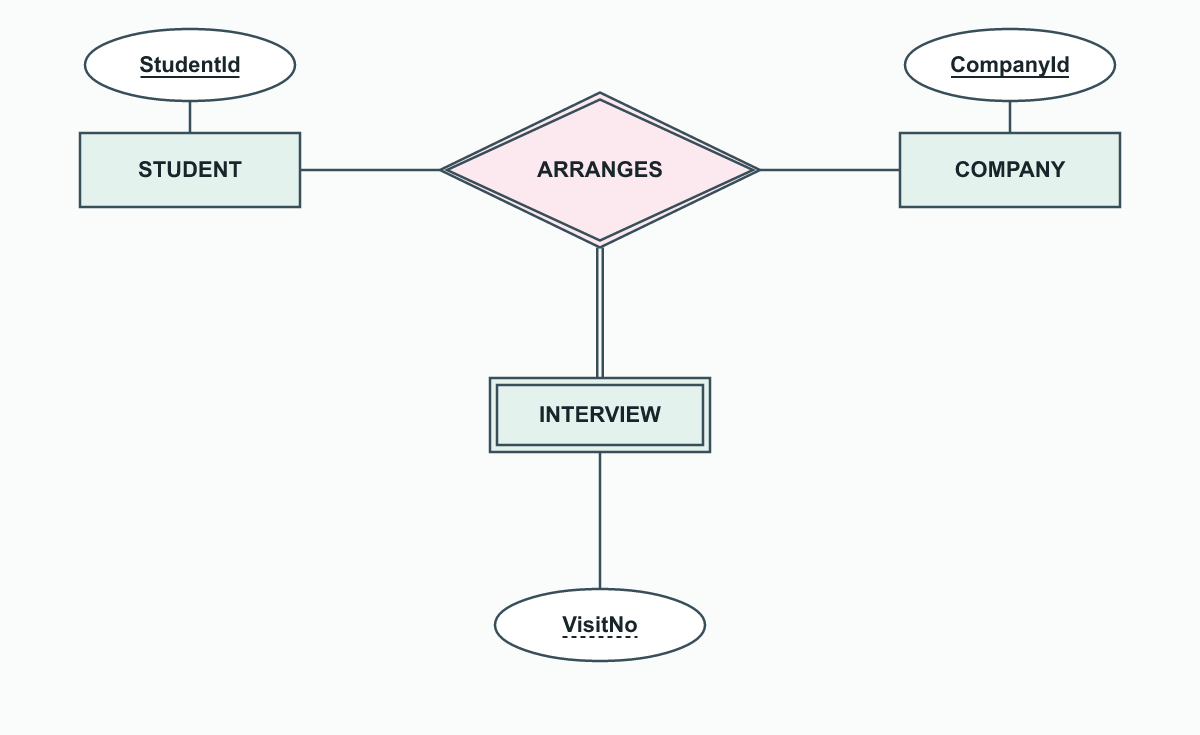

Fix both owners, then use VisitNo. StudentId or CompanyId plus VisitNo alone is insufficient.


### Read the Two-Owner Diagram

Neither works: the first combination repeats across the first two rows and the
second repeats across the first and third. The complete identity is
(StudentId, CompanyId, VisitNo). INTERVIEW is weak and has two owner types.
VisitNo distinguishes interviews only after both owners have been fixed.

The identifying relationship has three participants: STUDENT, COMPANY, and
INTERVIEW. The double line is on INTERVIEW's participation. This is an original
illustration of the multiple-owner idea in Section 3.9.1, not a copy of its job-offer example.

**Practice:** Add a second visit for S101 at C1. Explain why another first visit
for S101 at C1 would be a duplicate, even if its interview location changed.

A weak type normally has a partial key, but not every representation needs one.
If exactly one interview were allowed for each student-company pair, those two
owners alone could identify it. In that alternative design, VisitNo is unnecessary.
If repeated visits are allowed, the pair alone is insufficient.


### Choosing between an Attribute and a Weak Entity

Suppose only a list of phone labels and numbers is needed for each student.
A multivalued composite Contact attribute may be enough. If each contact must
also participate in a verification relationship with a staff member, representing
CONTACT as an entity lets that independent relationship be drawn explicitly.
With a label unique only within its student, CONTACT can be weak.

**Prediction:** Does being multivalued alone force Contact to be a weak entity?


### Check the Design Choice

No. Both representations can describe several contacts. The separate verification
relationship is a concrete reason to choose an entity representation.
For example, S101's "home" contact and S102's "home" contact remain distinct through
their owners. If no independent contact relationship is needed, the complex
attribute may be sufficient. This is a design choice based on requirements.

**Practice:** Give CONTACT a globally unique ContactId instead. Explain why it
can then be regular even though every contact still belongs to a student.


## 13. Refine a Design from Its Requirements

Design is iterative. An initial list may describe "teacher name" as a section
attribute. If the application also needs instructor identity, name, and teaching
assignments, an explicit INSTRUCTOR type and TEACHES relationship describe those
facts more clearly.

First identify instructors independently. Then associate each section with its
instructor. Keep Name on INSTRUCTOR rather than repeating it as the identity
of the teacher for every section.

**Prediction:** Do two sections with teacher name Morgan prove that the same
instructor teaches both?


### Replace an entity reference with a relationship

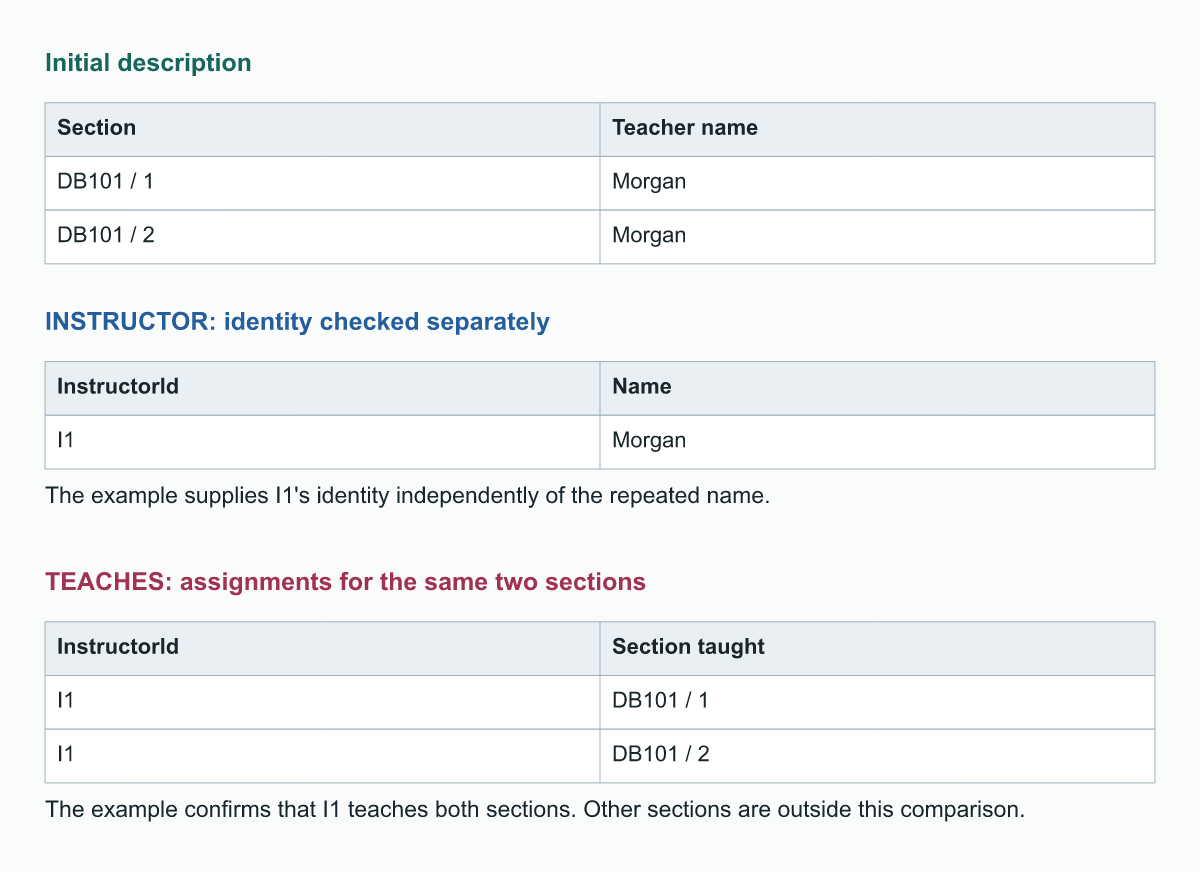

The same two sections remain. Name describes INSTRUCTOR; TEACHES records assignments. Matching names alone do not establish identity.


### Read the Diagram

No. Name equality is not a guaranteed identity rule. Read the figure from top
to bottom. The first table describes the two DB101 sections. The next table
records an independently identified instructor, I1, whose name is Morgan.
The final table explicitly assigns I1 to those same two sections. Those supplied
identity and assignment facts, not the repeated name alone, establish who teaches
what. The name is still present on INSTRUCTOR. Other sections, including
CS102 / 1, are outside this two-section comparison.

Use singular nouns for types, descriptive verbs for relationships, and role names
where needed. A noun in a requirement is a candidate for analysis, not an automatic
entity type. A location may remain an attribute if only its label is needed;
it may need its own type when independent room facts and relationships matter.

Do not invent a minimum from an incomplete statement such as "instructors teach
sections." Ask whether instructors may teach none and whether a section must
already have an instructor.

**Practice:** For "each course has a room," write two unanswered design questions
about sections and room sharing. Then state the extra information that would
justify treating ROOM as an entity rather than a simple label.


## 14. A Fact That Needs Three Participants

A **ternary relationship** has three participating roles. APPROVES records that
a particular instructor approved a particular student for a particular course.

The complete recorded approval set is:

| Record | Student | Instructor | Course |
|---:|---|---|---|
| 1 | S101 | I1 | DB101 |
| 2 | S101 | I2 | CS102 |
| 3 | S102 | I1 | CS102 |

Do not assume approval merely means that the instructor has met the student or
knows the course. Those would be different facts.

**Prediction:** The pairs S101-I1, S101-CS102, and I1-CS102 each occur somewhere
in the records. Does that prove approval (S101, I1, CS102) is recorded?


### One approval names a student, instructor, and course

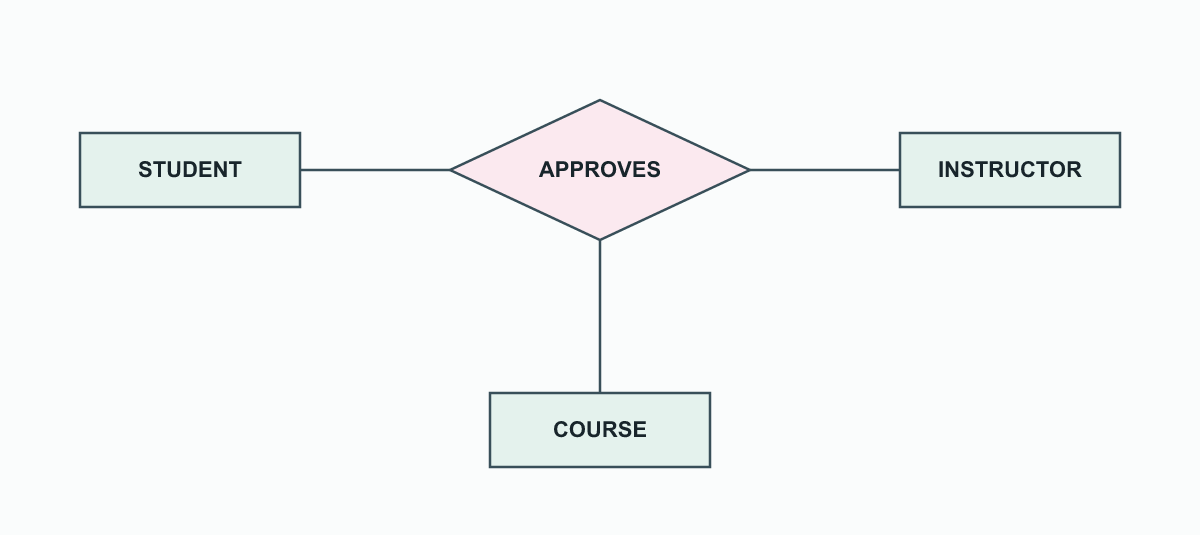

APPROVES is ternary. Each line connects a participating type to the same diamond; it is not a sequence.


### Three pairwise facts do not prove a three-way fact

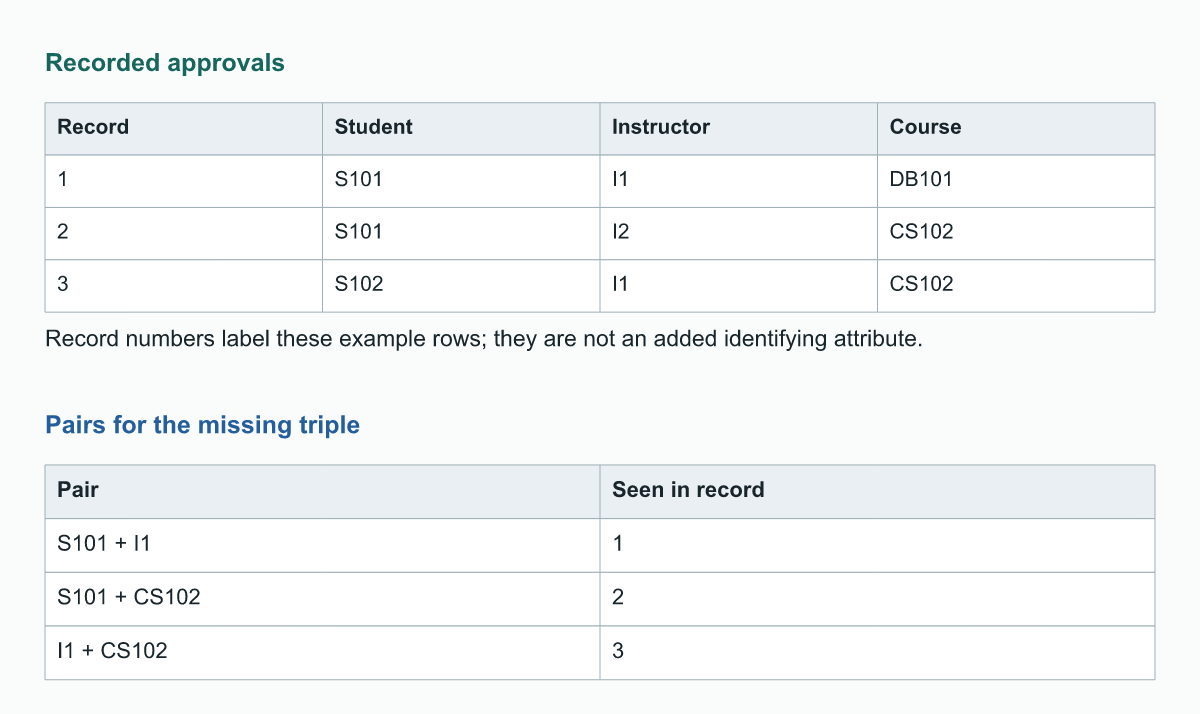

All three pairs for (S101, I1, CS102) appear, but that approval is absent from the supplied records.


### Read the Diagrams

Record 1 supplies S101-I1. Record 2 supplies S101-CS102.
Record 3 supplies I1-CS102. No record supplies all three together.
Joining the three pairwise observations in your reasoning can therefore suggest
a fact missing from the original set.

This counterexample shows why these pairs are insufficient for this case.
It does not claim that ternary relationships can never be represented another
way: additional constraints or a different conceptual representation may allow it.

The diamond has three undirected connections. It describes a simultaneous fact,
not a flow from student to instructor to course. Repeated approvals for the same
triple at different times would require an extended model.


### Worked Example: Two Approval Sets with the Same Pairs

Call the original three approvals state A. For state B, retain all of them
and add (S101, I1, CS102). Compare the full three-part facts and then the pairs
that can be read from each state. This comparison uses the core rules, before
the extra restrictions introduced in Sections 14.1-14.3.

**Prediction:** Does adding that approval create any new student-instructor,
student-course, or instructor-course pair?


### Pairwise information cannot distinguish these two states

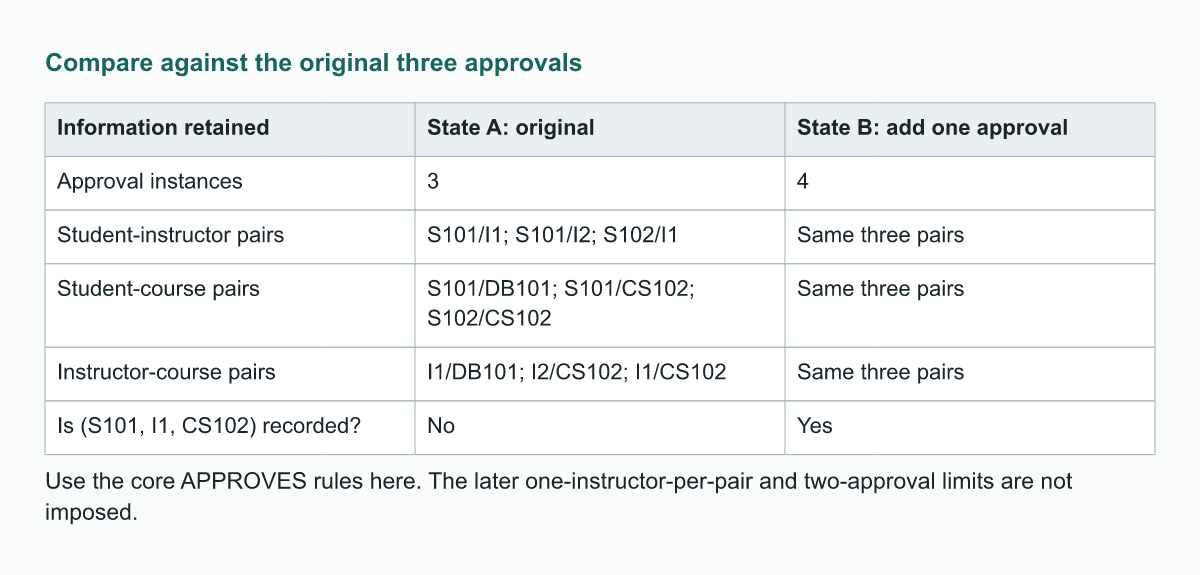

State B adds (S101, I1, CS102), but introduces no new pair. Keeping only the pairs loses whether that three-way approval is present.


### Read the Two Approval States

No new pair appears. S101/I1 already occurs in record 1; S101/CS102 in record 2;
I1/CS102 in record 3. Yet state A has three approvals and state B has four.
The two states answer the question about (S101, I1, CS102) differently.
The pairwise lists alone cannot tell which answer is correct.
This is a counterexample under these requirements, not a claim that every
ternary relationship in every model must be stored in one particular way.

**Practice:** Add exactly the missing approval to the complete recorded set.
Check whether any new pairwise combination appears. Compare the two full sets
to explain what the pairwise information cannot distinguish. No SQL join syntax
is needed for this reasoning.


### 14.1. Section 3.9.2: Fix Two Participants before Reading a 1

Keep the same three recorded approvals, but introduce this explicit rule for a
new variant: **for each student-course pair, at most one instructor may approve**.
Put 1 on the INSTRUCTOR connection and M and N on the other two connections.

For a ternary relationship, the 1 means that fixing the other two participants
allows at most one entity on this side. It does not mean that an instructor can
appear in only one approval overall. The student-course pair identifies an
approval instance under this rule. If all three labels are M or N, all three
participants are needed in general; additional stated rules could change that.

**Prediction:** Does I1 appearing in records 1 and 3 violate the 1 beside INSTRUCTOR?
Would adding (S101, I2, DB101) violate it?


### Fix student and course: at most one instructor

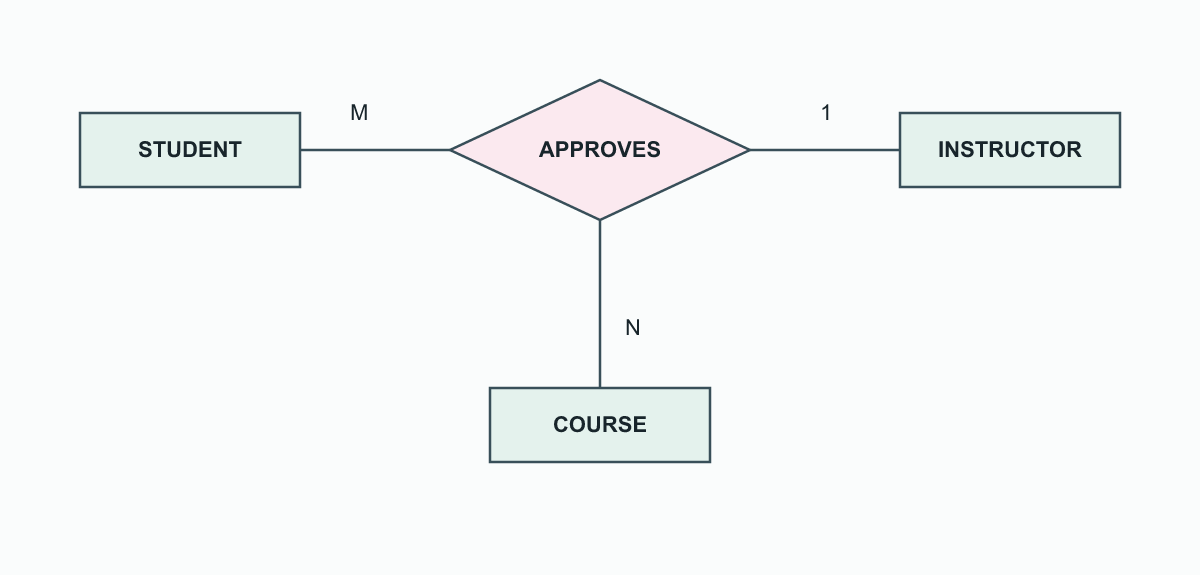

The 1 limits the instructor for a fixed student-course pair, not all approvals involving that instructor.


### Read the Ternary Maximum Diagram

I1 can approve S101 for DB101 and S102 for CS102: the student-course pairs differ.
The added record would give the fixed pair (S101, DB101) both I1 and I2.
That violates the rule, even though each of the three entities already exists.

For a relationship with n participating roles, the same reading fixes the
other n-1 participants.
Do not read the 1 as a limit on the total number of relationship instances
containing that instructor.

**Practice:** Add (S103, I1, DB101) instead. Name the pair you must fix before
deciding whether the maximum rule is violated.


### 14.2. Section 3.9.2: Count All Participations with Min-Max

Now impose a different rule for comparison: each instructor may participate
in zero, one, or two recorded approvals. Put (0,2) beside INSTRUCTOR.
Student and course participation is (0,N). These are illustrative limits,
not rules of the earlier core model or institutional policy.

**Prediction:** How many approvals involve I1 in the original three records?
Would adding (S103, I1, DB101) satisfy the instructor's (0,2) constraint?


### Count every approval involving one instructor

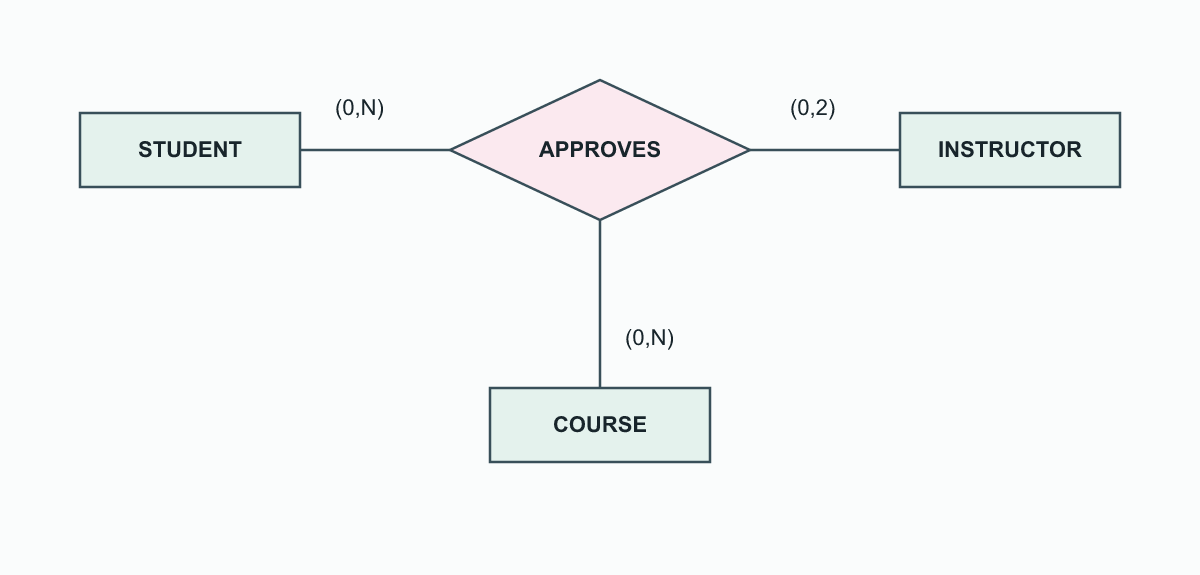

(0,2) permits zero to two approval instances per instructor; it does not enforce one instructor per student-course pair.


### Read the Ternary Participation Diagram

I1 participates twice, and I2 participates once. The proposed addition raises
I1's count to three, so it violates (0,2). It does not reuse a student-course pair,
so it passes the previous variant's pair-based maximum rule.

The two notations are **not interchangeable for ternary relationships**.
One constrains which instructor may complete a fixed student-course pair.
The other limits the number of approval instances involving one instructor.
Unlike the binary translation in Section 9, replacing one notation with the
other would lose a requirement.

**Practice:** Add (S101, I2, DB101) to the original set and count I2's participations.
Then test the fixed student-course pair separately. Keep the original inputs
the same for both checks.


### 14.3. Use Both Checks When Both Rules Are Required

Assume both rules now apply: at most one instructor per student-course pair,
and at most two approvals per instructor. Each proposed addition below is tested
separately against the original three records, not after the preceding addition.

| Proposed addition | Check the fixed student-course pair | Check total approvals per instructor |
|---|---|---|
| S101, I2, DB101 | Does the pair already have another instructor? | How many approvals would I2 have? |
| S103, I1, DB101 | Does the pair already have another instructor? | How many approvals would I1 have? |
| S103, I2, DB101 | Does the pair already have another instructor? | How many approvals would I2 have? |

**Prediction:** Which addition passes both checks?


### Test the same proposed addition against two different rules

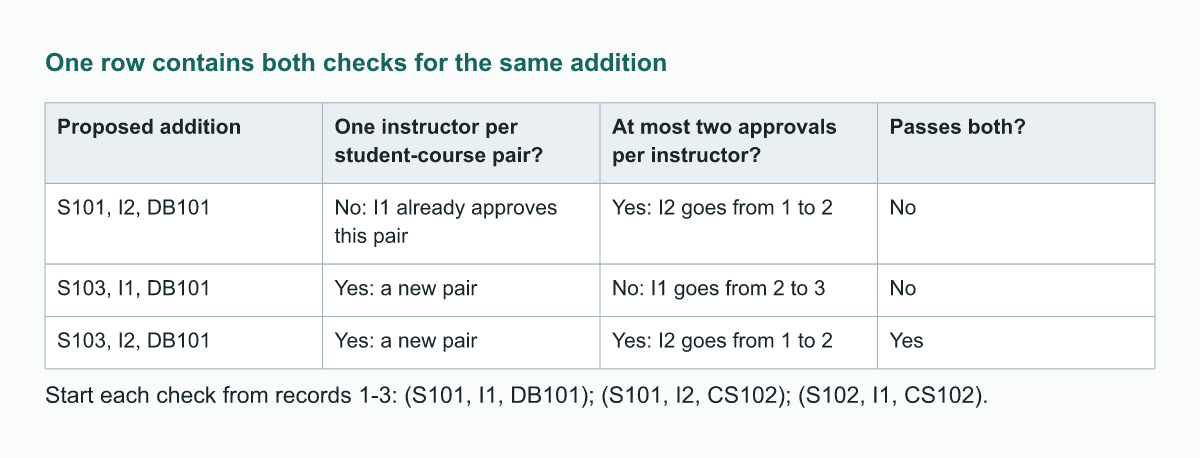

Each row starts from the original three approvals. Only (S103, I2, DB101) passes both rules.


### Read the Two-Check Table

The first fails the pair rule but leaves I2 with two approvals.
The second uses a new pair but gives I1 three approvals.
The third uses a new pair and leaves I2 with two approvals, so it passes both.
Each figure row keeps the proposed addition, both checks, and the combined
decision together. The count is recomputed from the original records each time.

A pair-based restriction and a participation bound must both be retained when
both are requirements. We show the two diagrams separately and state their
conjunction explicitly, so the labels cannot be mistaken for one notation.
For higher-degree relationships, do not infer the identifying combination
merely from total-participation counts.

**Practice:** Propose another addition that passes both rules and one that fails
only the total-count rule. Record the fixed pair and the before/after count.
This remains paper reasoning; no relational mapping is required.


## 15. Assemble the Campus Diagram

Build the core diagram in this order:

1. Draw STUDENT, INSTRUCTOR, COURSE, and weak SECTION.
2. Add their keys, the partial key of SECTION, and STUDENT's multivalued Phone.
3. Connect COURSE and SECTION with identifying HAS_SECTION.
4. Connect INSTRUCTOR and SECTION with TEACHES.
5. Connect STUDENT and SECTION with ENROLLS_IN, then add Grade to the relationship.
6. Connect STUDENT, INSTRUCTOR, and COURSE to the single APPROVES diamond.
7. Check each binary relationship's maximum counts and participation separately.

This is the deliberately small **core** model from Section 1. The expanded
profile, room, card, and mentoring examples illustrate other concepts; they
are not silently added to the core requirements.

**Prediction:** Which two relationships require total participation by SECTION?
Does the total-participation line in either one require every student to enroll?


### The core campus ER schema for Fall 2026

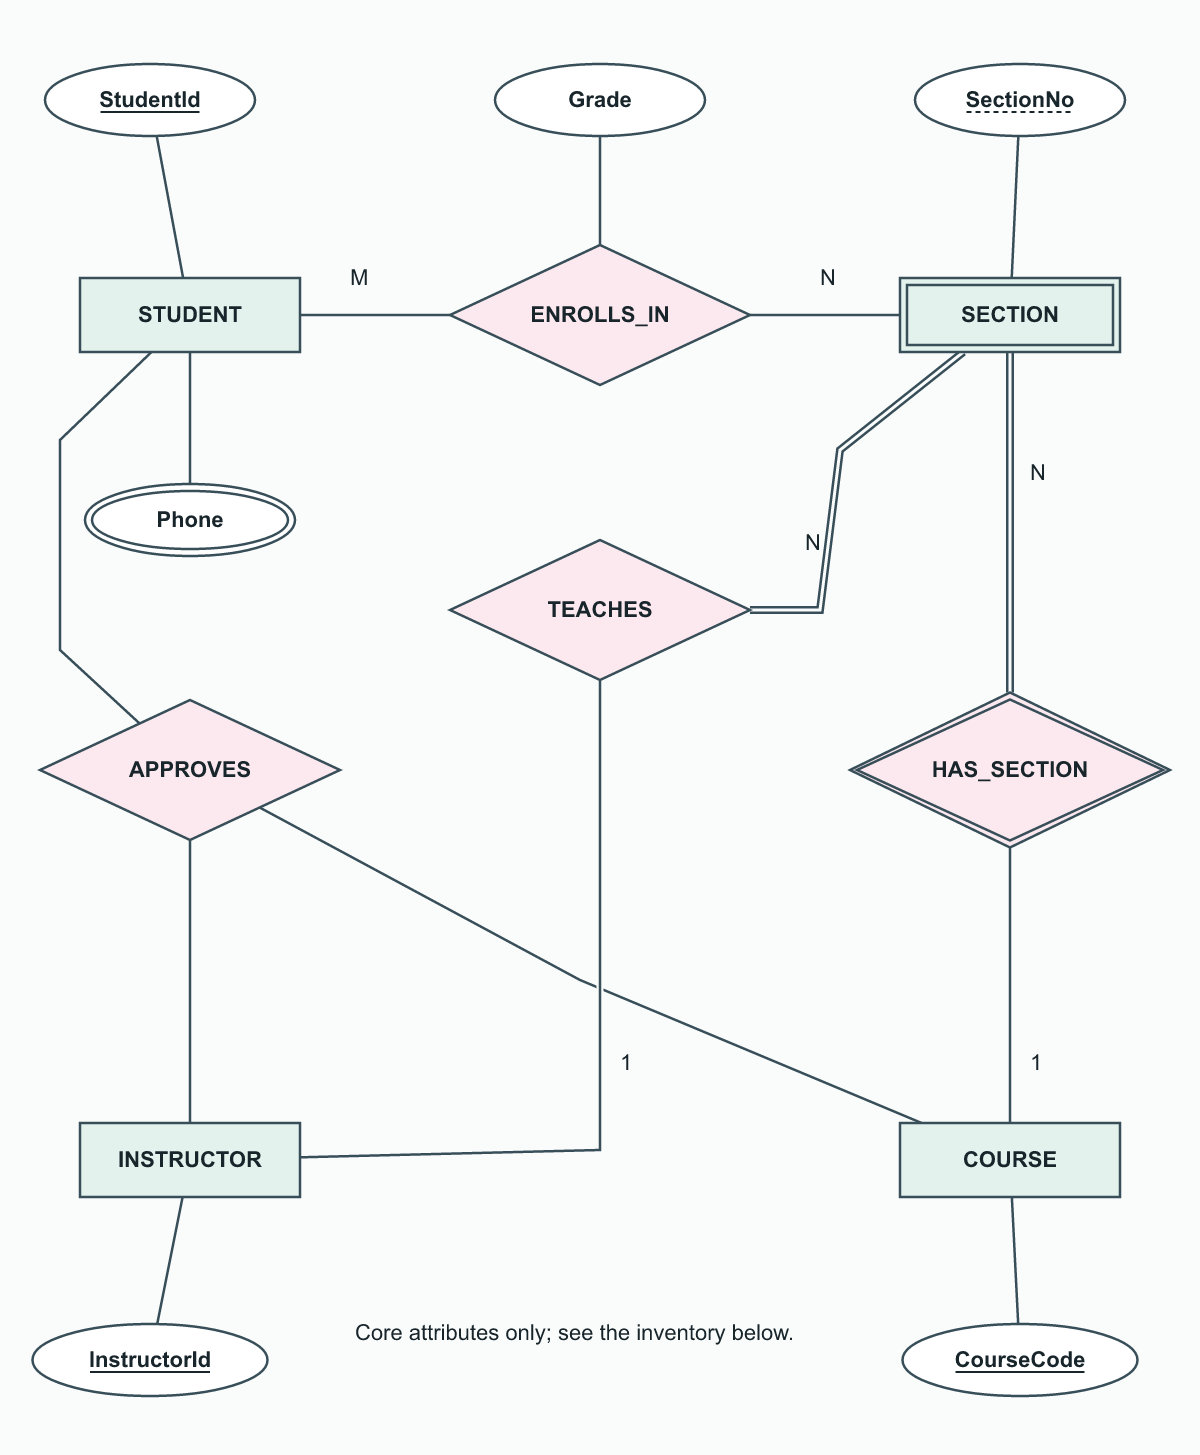

Maximum ratios and double participation lines describe the binary relationships. APPROVES records three-way facts.


### Read the Diagram

SECTION participates totally in HAS_SECTION and TEACHES: it must have both
an owner course and an instructor. Those constraints do not apply to STUDENT's
participation in ENROLLS_IN. S103 may still have no enrollment.

Here the diagram returns to maximum ratios and single/double participation
lines, not the alternative min-max convention. Bent lines have the same meaning
as straight ones. A line crossing is not a relationship or a junction; only
named endpoints define participation.

The complete core attribute inventory is intentionally small:

| Type or relationship | Attributes in the core |
|---|---|
| STUDENT | StudentId, Phone (multivalued) |
| INSTRUCTOR | InstructorId |
| COURSE | CourseCode |
| SECTION | SectionNo (partial key) |
| ENROLLS_IN | Grade, unknown until available |

Read this diagram as a schema for possible legal states, not as a picture of
only today's sample records. The sample data demonstrate consequences; they
do not establish the requirements.

**Practice:** Redraw the diagram from Section 1 without looking at the figure.
For each binary relationship, write two sentences, one from each participating
type's point of view. Test an empty course, an unassigned section, a student with
no enrollment, and two students sharing one section. Cite the exact requirement
for each decision. Retain the ternary approval fact as a three-part fact.


## 16. Section 3.10: A UNIVERSITY Database

Now move from the small one-term teaching model to the book's larger UNIVERSITY
case (pp.122-124, Figure 3.20). **These are different requirements**, not a correction
that makes every SECTION weak or every SECTION strong.

This case includes several years of sections, a globally unique SecId, and at
least five students in each section. The earlier core allows an empty section
and identifies it through a course within one term. Keep the two sets of rules separate.

**Prediction:** Which earlier weak-entity symbol must change when SecId alone
identifies every section across all stored terms?


### Read the Change in Requirements

SECTION is regular here: SecId is its own key. Draw a single rectangle and an
ordinary SECS relationship to COURSE. SECTION still requires one course and
one instructor. Required relationships do not remove its independent key.

**Practice:** State two other rules that differ from the earlier core, and show
a small state allowed by one model but forbidden by the other.


### 16.1. Identify the Entities and Attributes

Begin with six types. The inventory below paraphrases the source requirements;
identifiers and attribute names match the book where useful for comparison.

| Type | Identifying attributes | Other information |
|---|---|---|
| COLLEGE | CName | COffice, CPhone |
| DEPT | DCode and DName are independent keys in the requirements | DOffice, DPhone |
| COURSE | CCode and CoName are independently unique in the requirements | Level, Credits, CDesc |
| INSTRUCTOR | Id | IName, IOffice, IPhone, Rank |
| STUDENT | SId | SName(FName, MName, LName), Addr, Phone, Major, DOB |
| SECTION | SecId, globally unique | SecNo, Sem, Year, CRoom(Bldg, RoomNo), DaysTime |

SName and CRoom are composite attributes. Grade belongs to TAKES, not STUDENT
alone. CStartDate belongs to CHAIR, because it records when a particular instructor
began chairing a department. Level describes the course's study level:
1 through 4 for undergraduate years, 5 for master's level, and 6 for doctoral level.
These are the book's example codes, not a new rule for this course.

Figure 3.20 underlines both CCode and CoName. Each independently identifies a
course under the stated requirements. They are two separate keys, not one
composite key consisting of both attributes.

**Prediction:** A section is in building A, room 201. Which two components belong
under CRoom? Does SecNo become a global key because SecId is one?


### In Section 3.10, SECTION has a globally unique SecId

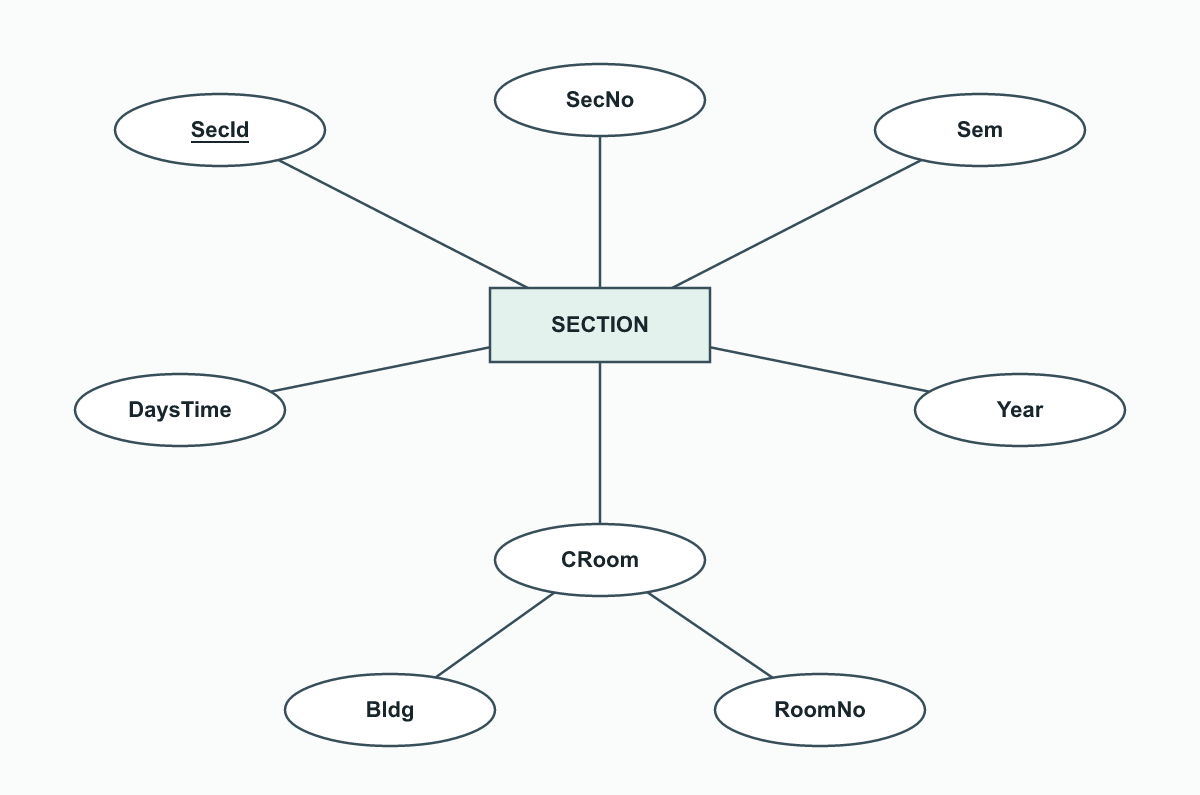

SecId is a full key. CRoom has Building and RoomNo components; SecNo is not a global identifier.


### Read the Section Attributes

CRoom contains Bldg and RoomNo. The SecId oval is underlined; SecNo is not.
Two sections can use SecNo 1 in different courses or terms while having different
SecId values. Entity attributes describe a section; the related course and
instructor are connected through relationships rather than extra ER key ovals.

**Practice:** Draw STUDENT with its composite SName and its key SId.
Then attach Grade to TAKES and explain the two participants needed to interpret it.


### 16.2. Build the Organization and Staff Relationships

Read Figure 3.20 in small parts. The next diagram uses min-max notation beside
the entity whose participation is counted. Repeated rectangles with the same
name denote the same entity type across the panels; they are not new types.

| Relationship | Left participant and count | Right participant and count |
|---|---|---|
| ADMINS | COLLEGE (0,N) | DEPT (1,1) |
| DEAN | COLLEGE (1,1) | INSTRUCTOR (0,1) |
| CHAIR | DEPT (1,1) | INSTRUCTOR (0,1) |
| EMPLOYS | DEPT (0,N) | INSTRUCTOR (1,1) |
| HAS | DEPT (0,N) | STUDENT (0,1) in the figure |

**Prediction:** Does an instructor who chairs a department automatically have
to be that department's employee according to these connections alone?


### Read the organization one relationship at a time

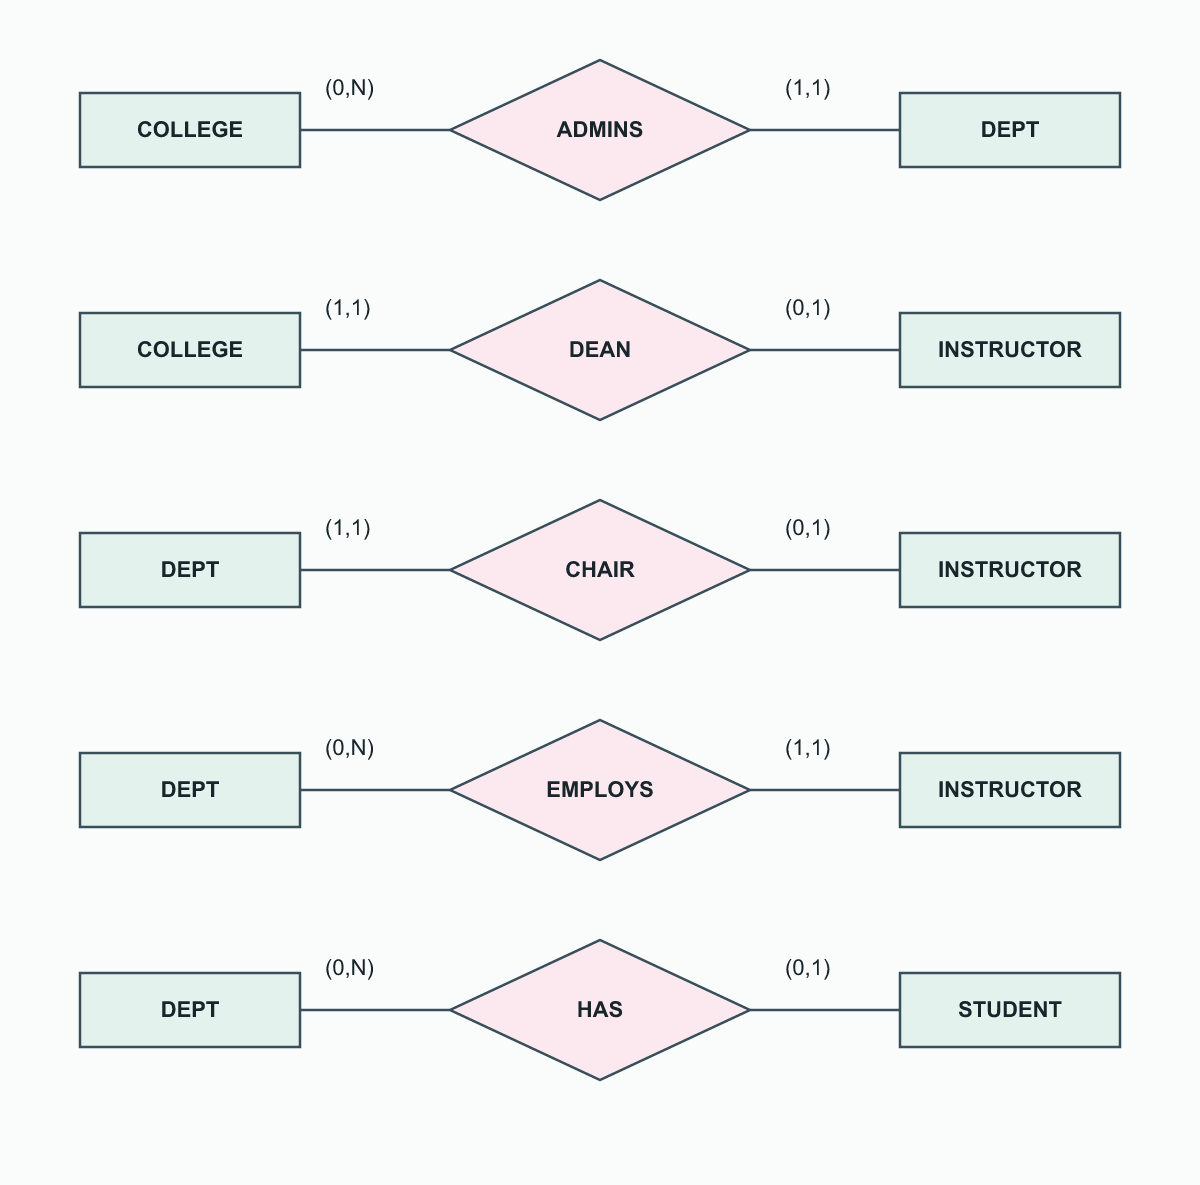

Counts follow Figure 3.20. HAS shows STUDENT (0,1); the prose instead requires (1,1). Keep that discrepancy explicit.


### Read the Organization Diagrams

No. CHAIR and EMPLOYS are different relationships. Matching their department
participants requires an additional rule. Likewise, dean membership in the
college's departments is not established merely by having these relationship types.

For an invented snapshot, let college C-A administer departments D1 and D2.
I1 is dean of C-A, I1 chairs D1, I2 chairs D2, and each works in the department
they chair. A third instructor I3 may work in D1 without being a dean or chair.
These facts satisfy the displayed maxima; they do not prove those rules universally.

There is a source inconsistency worth reading carefully: the prose on p.123
assigns each student to one primary department, but HAS in Figure 3.20 shows
(0,1) beside STUDENT. Our diagram faithfully labels the figure's (0,1);
the prose version would instead use (1,1). Do not silently merge the two.
A student with no department passes the figure's version and fails the prose version.
For this exercise, identify which version you are checking.


### Worked Example: A Chair Is Not Every Employee

Use the invented C-A, D1, D2, I1, I2, and I3 snapshot just described.
The next table lists the organization facts explicitly. It leaves out appointment
dates and other attributes to isolate the relationships being counted.

**Prediction:** I3 appears in EMPLOYS but not CHAIR. Which minimum must I3 satisfy?
Does I3 have to become a chair to satisfy it?


### Read CHAIR and EMPLOYS as separate facts

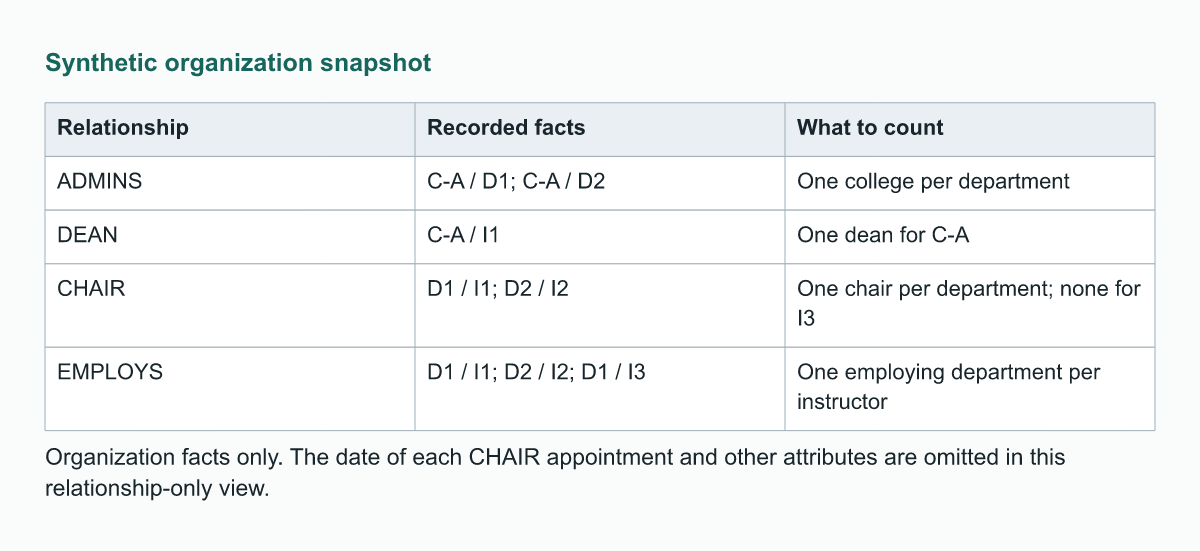

I3 works in D1 but chairs no department. That satisfies both rules: employment is required, chairing is optional for an instructor.


### Read the Organization Facts

I3 must have one employing department and does: D1. I3 may chair zero departments,
so the absent CHAIR fact is permitted. D1 and D2 must each have a chair, and
the table supplies I1 and I2 respectively. Count both directions separately.
The sample chooses chairs who work in their departments, but CHAIR and EMPLOYS
do not by themselves enforce that cross-relationship condition.

**Practice:** Give I3 no department. Test EMPLOYS without confusing it with CHAIR.
Then redraw HAS for the prose requirement and state the one changed minimum.
Attach a start date to a CHAIR instance, not to all of an instructor's roles.


### 16.3. Connect Courses, Sections, Teachers, and Students

The remaining relationships connect teaching and enrollment. Keep Figure 3.20's
min-max convention; the counts belong beside the participating entity.

| Relationship | Left participant and count | Right participant and count |
|---|---|---|
| OFFERS | DEPT (0,N) | COURSE (1,1) |
| SECS | COURSE (0,N) | SECTION (1,1) |
| TEACHES | INSTRUCTOR (0,N) | SECTION (1,1) |
| TAKES | STUDENT (0,N) | SECTION (5,N) |

For a synthetic example, Q101 is one section of DB101, taught by I1.
Students U1 through U5 take Q101. A grade can be absent until it is available.
These are five distinct enrollment facts, not five duplicates of one student's fact.

**Prediction:** If U5 leaves and nobody replaces U5, which minimum is violated?
Does an instructor with no sections violate TEACHES?


### Link courses and sections without making SECTION weak

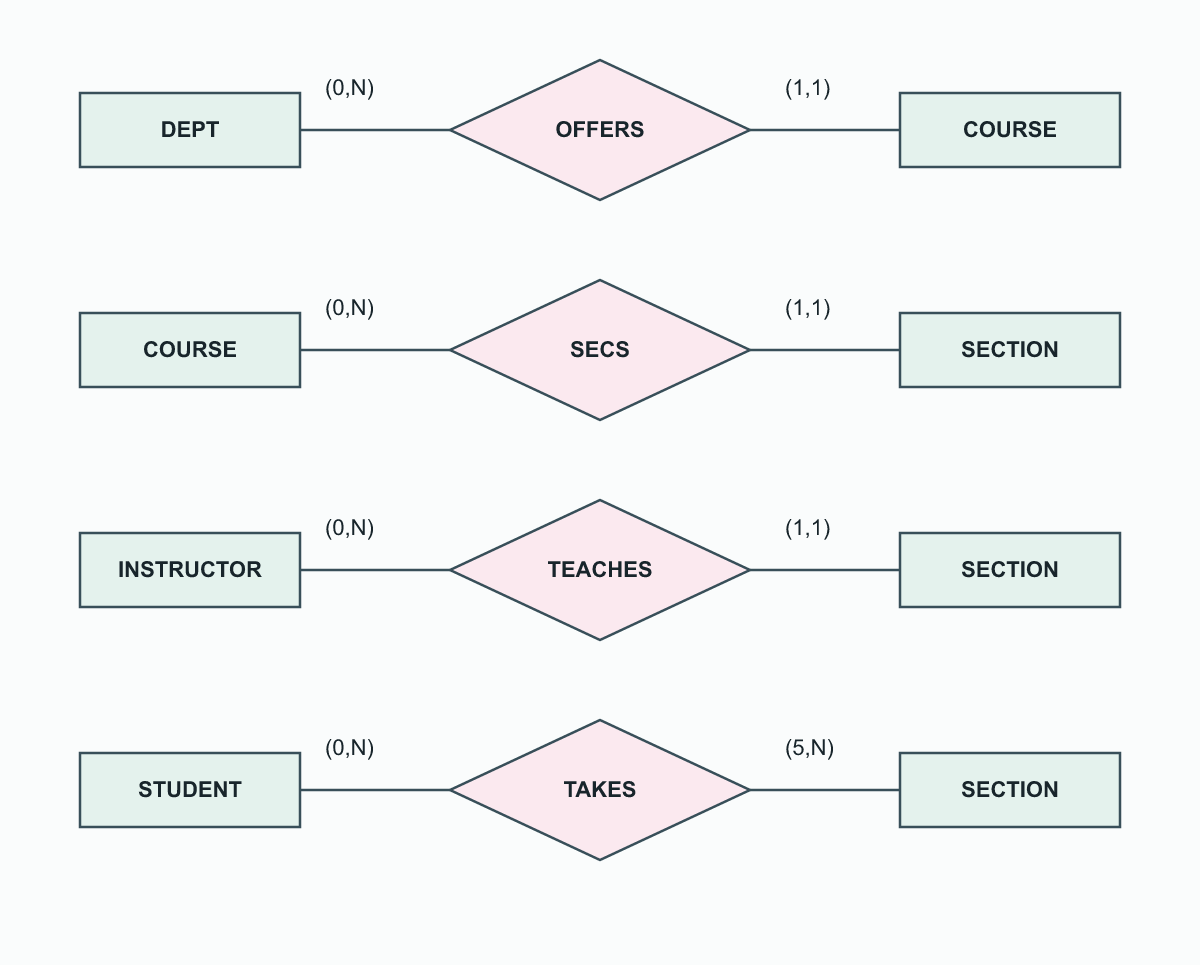

Each SECTION needs a course, an instructor, and at least five students. A COURSE may have no section.


### Read the Teaching Diagrams

Q101 would have four students and violate SECTION's (5,N) participation in TAKES.
An instructor with no teaching assignments satisfies (0,N).
Neither condition changes SECTION's own key SecId.

Together, the organization panels and these teaching panels cover all nine
relationship types in Figure 3.20. Combine repeated entity types into six
rectangles to assemble the complete design. Add the attribute inventory, Grade
on TAKES, and CStartDate on CHAIR. These original layouts explain the source
without reproducing its page image.


### Worked Example: Five Distinct Students Become Four

Keep Q101's identity, course DB101, and instructor I1 fixed. Initially U1 through
U5 take Q101. Now remove only the U5/Q101 TAKES fact; U5 can remain a student.

**Prediction:** Does keeping U5 in STUDENT keep Q101's TAKES count at five?


### Removing one TAKES fact can violate a minimum

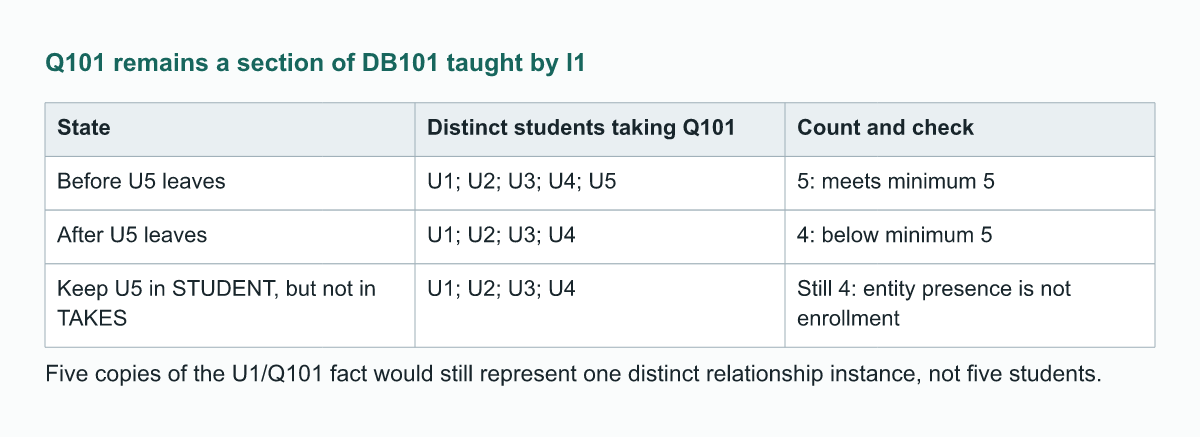

After U5 leaves, Q101 still has its SecId, course, and instructor, but its four TAKES instances violate this UNIVERSITY model's minimum of five.


### Read the Enrollment Change

No. The count is four because only U1 through U4 still participate in TAKES
with Q101. The student entity set and the relationship set answer different
questions. Duplicating U1/Q101 on paper cannot create another distinct student
or another distinct instance of the same relationship fact.
The earlier core would allow a section with four enrollments, because it has
no minimum of five. The change in outcome comes from the different requirements.

**Practice:** Compare the state with four students against the earlier core's
ENROLLS_IN rule. Explain why it is legal there but not in this UNIVERSITY example.
Then reconstruct OFFERS, SECS, and TEACHES while keeping their different participants.


### 16.4. Some Uniqueness Rules Need More Than a SecId Oval

SecId distinguishes section objects, but different IDs alone do not prevent
duplicate section numbers or scheduling conflicts.

Under the additional rules discussed on p.123, check these combinations:

| Combination that must not repeat | What a repetition would mean |
|---|---|
| Course, Sem, Year, SecNo | Two sections have the same local number in the same course and term. |
| Sem, Year, CRoom, DaysTime | Two sections occupy the same room at the same scheduled time. |
| Sem, Year, instructor, DaysTime | One instructor teaches two sections at the same scheduled time. |

Course and instructor here identify related entities; they are not newly added
standalone SECTION attributes. The instructor rule assumes combined sections
are not permitted, as the source explicitly qualifies.

Use a new isolated proposed pair for each check:

| Case | SecId values | Facts shared by the two sections | Result to predict |
|---|---|---|---|
| A | Q101, Q102 | DB101, Fall, 2026, SecNo 1 | Local section-number conflict? |
| B | Q201, Q202 | Fall, 2026, room A/201, Thu-P5 | Room conflict? |
| C | Q301, Q302 | Fall, 2026, instructor I1, Thu-P5 | Instructor conflict? |

The IDs are different in every case. Unlisted fields can be chosen differently
so each example isolates the named rule.

**Prediction:** Does unique SecId alone make any of these pairs acceptable?


### Different section IDs do not prevent other conflicts

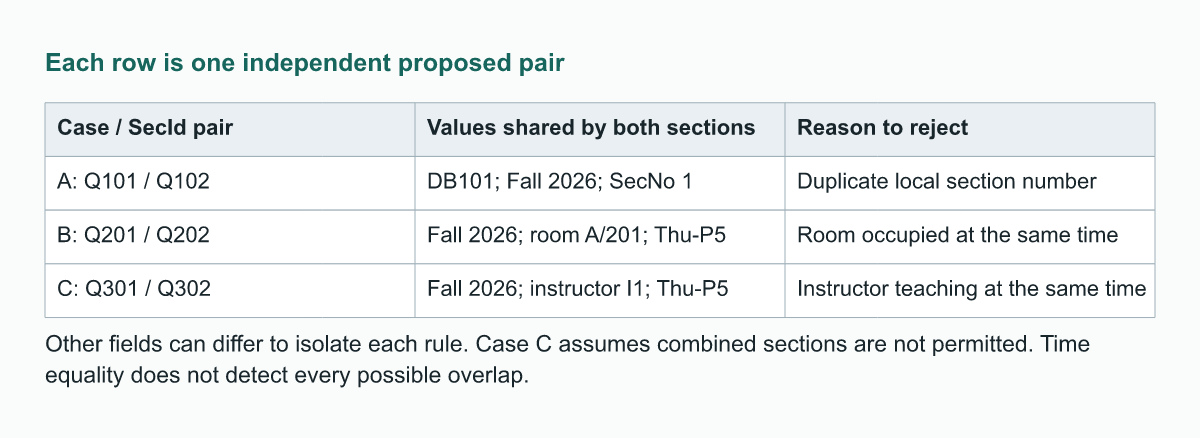

Each pair has different SecId values but violates its named extra rule. The three cases are checked independently.


### Read the Conflict Table

All three proposed pairs violate their named additional rule despite different
SecId values. In case A, changing the second SecNo to 2 removes the named
number conflict. In B, a different nonoverlapping time removes the named room
conflict. In C, a different teacher or nonoverlapping time removes the named
instructor conflict. Other requirements must still be checked.

Exact equality of DaysTime detects identical stored time patterns.
If arbitrary overlapping intervals are allowed, different labels could still
overlap; the simple combination check is then insufficient. This is a limitation
of the equality illustration, not a claim that the book provides a complete scheduler.

**Practice:** Move the second section in case A to Spring 2027 and check the
course-term-number combination again. Then give two differently named time
intervals that overlap and explain why equality alone misses that conflict.


## 17. Compare Designs and Practice

Use the same requirements for every group's design:

- A section belongs to exactly one course.
- SectionNo is unique only within its course.
- A section has exactly one instructor; an instructor may teach none or several.
- A student may enroll in none or several sections.
- A section may have none or several students.

Each group draws COURSE, SECTION, INSTRUCTOR, and STUDENT with these relationships
and constraints, and explains its identification choice. Compare the same facts,
not artistic style or the number of colors used. A diagram may use either of
the two taught constraint notations if it uses that notation consistently.

After the group responses are fixed, compare the anonymously displayed responses
individually. For each response, test DB101 / 1 alongside CS102 / 1, an instructor
with no assignment, and a section with two instructors. Use those checks to
explain your ordering of the responses. The instructor will discuss the technical
reasons before you revise your own drawing. Peer ranking does not determine grades.

Keep your own drawing and one checked prediction as learning notes. Include one
prediction, the observed result, and either your correction or an explanation
of why your prediction was correct. Submit only the work the instructor assigns.

For further individual practice, change one requirement at a time:

| Change | What to inspect |
|---|---|
| Team teaching is allowed. | The maximum instructor count per section |
| Every student must enroll somewhere. | The minimum participation of STUDENT in ENROLLS_IN |
| Several terms must be retained. | Whether the current section identity still distinguishes all sections |
| One globally unique SectionId is supplied. | Whether identification still depends on the owner |

Do not treat a permitted state as a required state, and do not change unrelated
rules to make a proposed diagram work.


## Chapter Summary and Next Chapter

An entity type describes objects; an entity set records the objects currently
present. Attributes describe properties. Keys identify entities under rules
that apply to all legal states.

Relationships connect participating entities. Maximum cardinality and minimum
participation answer different questions. A relationship attribute describes
a particular connection. A weak entity needs its owner's identity, and a ternary
fact may contain information lost by considering pairs alone. For ternary
relationships, fixing other participants and counting total participation are
different checks. The UNIVERSITY case illustrates how changed identification,
minimum-enrollment, and multi-term requirements change a design.

Ch4 adds the **Enhanced Entity-Relationship (EER) model**. It will ask how a
general type and more specialized types can share properties, and how membership
rules should be represented. Keep this campus model for that discussion.
Relational mapping and SQL implementation come later; they are not prerequisites
for completing this chapter's drawings.


## Textbook Reading

The explanations and examples use original wording and synthetic data.
The conceptual definitions follow Chapter 3 of the prescribed book.

| Material here | Textbook sections and printed pages |
|---|---|
| Requirements and conceptual design | 3.1-3.2, pp.90-93 |
| Entities, attributes, keys, domains | 3.3, pp.93-102 |
| Relationships, roles, constraints, relationship attributes | 3.4, pp.102-108 |
| Weak entities, nested owners, and multiple owners | 3.5, p.109; 3.9.1, pp.120-121 |
| Refinement, ER symbols, min-max notation | 3.6-3.7, pp.110-115 |
| Simple ternary relationship | 3.9.1, pp.118-121 |
| Ternary and higher-degree constraints | 3.9.2, pp.121-122 |
| UNIVERSITY requirements, diagram, and additional uniqueness rules | 3.10, pp.122-124; Figure 3.20 |

Page numbers refer to the photographed classroom copy. Chapter and section
numbers are the preferred locators when another printing has different pagination.

Detailed UML notation in Section 3.8 is not assigned here. The new UNIVERSITY
walkthrough paraphrases the source and explicitly identifies its prose/figure
differences; its input records and diagram layouts are original teaching examples.
